## README

Annotate potential novel peptide/proteins from PacBio long-read RNA seq  
Infer the translation trap/stall mechanism

Input:
- Mapped BAM file after quality control
- Annotated genome gff and FASTA file

Output:
- Excel file: RNA Isoform annotation, Novel ORF annotation
- FASTA file: protein seq

FASTA file will be used in mass spectrometry based proteomics analysis.

## Locate Abnormal Transcripts

Label per isoform against the known gene annotation.

### All isoforms

In [ ]:
# ============================================================
# Isoform clustering + annotation against genes
# Regenerated version:
#   - NO QC filtering here (use your pre-filtered BAM directly)
#   - FIXED coordinate bug for minus-strand isoforms
#   - stores both transcript-oriented 5'/3' and genomic start/end
#
# Input:
#   - high-confidence BAM
#   - genome GFF/GFF3
#
# Output:
#   - isoform_clusters_annotated.tsv
#   - isoform_clusters_annotated.xlsx
#   - optional isoform_membership.tsv
# ============================================================

from __future__ import annotations
import os
from pathlib import Path
from typing import Optional, Tuple, List, Dict

import numpy as np
import pandas as pd
import pysam


# ----------------------------
# Inputs
# ----------------------------
MOTHER_FOLDER = ".."   # change if needed
BAM_PATH = MOTHER_FOLDER + "/syn1.PacBio.FLNC.sorted.HQ.bam"   # change if needed
GFF_PATH = MOTHER_FOLDER + "/Genomes_Input/syn1.genes.gff3"                   # change if needed

OUT_FOLDER = MOTHER_FOLDER + "/isoform_annotation"
Path(OUT_FOLDER).mkdir(parents=True, exist_ok=True)

OUT_ISOFORMS_TSV   = OUT_FOLDER + "/isoform_clusters_annotated.tsv"
OUT_ISOFORMS_XLSX  = OUT_FOLDER + "/isoform_clusters_annotated.xlsx"
OUT_MEMBERSHIP_TSV = OUT_FOLDER + "/isoform_membership.tsv"   # set to None to disable

In [ ]:
# ----------------------------
# BAM handling
# ----------------------------
REQUIRE_PRIMARY = True   # keep only primary alignments


# ----------------------------
# Isoform clustering parameters
# ----------------------------
# grouping is by transcript-oriented 5' and 3' ends
BIN5 = 20
BIN3 = 30

MIN_ISOFORM_READS = 2

DO_POST_MERGE = True
MERGE_5P_TOL_BP = 15
MERGE_3P_TOL_BP = 15


# ----------------------------
# Gene / annotation rules
# ----------------------------
GENE_FEATURE_TYPES = {"gene", "CDS"}   # prefer gene, fallback CDS
GENE_ID_KEYS       = ["locus_tag", "ID", "Name", "gene", "gene_id"]
GENE_NAME_KEYS     = ["gene", "Name", "product", "locus_tag", "ID"]

MIN_GENE_OVERLAP_BP = 50
PURE_FRAC = 0.95


# ----------------------------
# Helpers
# ----------------------------
def overlap_len(a0: int, a1: int, b0: int, b1: int) -> int:
	return max(0, min(a1, b1) - max(a0, b0))

def mad(x: np.ndarray) -> float:
	if x.size <= 1:
		return 0.0
	m = np.median(x)
	return float(np.median(np.abs(x - m)))

def bin_pos(pos0: int, binsz: int) -> int:
	return int((pos0 // binsz) * binsz)

def aligned_interval_and_ends(read: pysam.AlignedSegment) -> Optional[Dict[str, int]]:
	"""
	Returns a dict with:
	  strand  : '+' or '-'
	  g_start0: genomic interval start (0-based, inclusive)
	  g_end0  : genomic interval end   (0-based, exclusive)
	  pos5p0  : transcript-oriented 5' aligned end
	  pos3p0  : transcript-oriented 3' aligned end

	Softclips are excluded because pysam reference_start/reference_end
	are aligned coordinates.
	"""
	r0 = read.reference_start
	r1 = read.reference_end
	if r0 is None or r1 is None or r1 <= r0:
		return None

	strand = "-" if read.is_reverse else "+"

	if strand == "+":
		pos5p0 = int(r0)
		pos3p0 = int(r1)
	else:
		pos5p0 = int(r1)
		pos3p0 = int(r0)

	return {
		"strand": strand,
		"g_start0": int(r0),
		"g_end0": int(r1),
		"pos5p0": pos5p0,
		"pos3p0": pos3p0,
	}

def parse_gff_attributes(attr_str: str) -> Dict[str, str]:
	d = {}
	if pd.isna(attr_str):
		return d
	for field in str(attr_str).split(";"):
		field = field.strip()
		if not field:
			continue
		if "=" in field:
			k, v = field.split("=", 1)
		elif " " in field:
			k, v = field.split(" ", 1)
			v = v.strip('"')
		else:
			continue
		d[k.strip()] = v.strip()
	return d

def first_attr(attrs: Dict[str, str], keys: List[str], default: str = "") -> str:
	for k in keys:
		if k in attrs and attrs[k] not in ("", ".", None):
			return str(attrs[k])
	return default

def load_genes_from_gff(gff_path: str,
						feature_types: set[str] = {"gene", "CDS"}) -> pd.DataFrame:
	rows = []
	with open(gff_path, "r") as fh:
		for line in fh:
			if not line.strip() or line.startswith("#"):
				continue
			parts = line.rstrip("\n").split("\t")
			if len(parts) != 9:
				continue
			chrom, source, feature, start1, end1, score, strand, phase, attrs = parts
			if feature not in feature_types:
				continue
			if strand not in {"+", "-"}:
				continue

			try:
				start1 = int(start1)
				end1   = int(end1)
			except ValueError:
				continue

			if end1 < start1:
				continue

			attrd = parse_gff_attributes(attrs)
			gene_id   = first_attr(attrd, GENE_ID_KEYS, default="")
			gene_name = first_attr(attrd, GENE_NAME_KEYS, default=gene_id)

			rows.append({
				"chrom": chrom,
				"start0": start1 - 1,  # GFF 1-based inclusive -> 0-based half-open
				"end0": end1,
				"strand": strand,
				"gene_id": gene_id if gene_id else f"{feature}:{chrom}:{start1}-{end1}:{strand}",
				"gene_name": gene_name if gene_name else gene_id,
				"feature_type": feature,
			})

	df = pd.DataFrame(rows)
	if df.empty:
		raise ValueError("No gene/CDS features parsed from GFF.")

	if (df["feature_type"] == "gene").any():
		df = df[df["feature_type"] == "gene"].copy()
	else:
		df = df[df["feature_type"] == "CDS"].copy()

	df = df.sort_values(["chrom", "start0", "end0", "strand"]).reset_index(drop=True)
	return df

def post_merge_isoforms(df: pd.DataFrame,
						tol5: int = 15,
						tol3: int = 15) -> pd.DataFrame:
	"""
	Merge isoforms within each (chrom, strand) if transcript-oriented
	5' and 3' ends are close.
	"""
	if df.empty:
		return df.copy()

	out_rows = []

	for (chrom, strand), g in df.sort_values(
		["chrom", "strand", "pos5p0", "pos3p0"]
	).groupby(["chrom", "strand"], sort=False):

		current = None

		for row in g.to_dict("records"):
			if current is None:
				current = row.copy()
				continue

			same_5 = abs(int(row["pos5p0"]) - int(current["pos5p0"])) <= tol5
			same_3 = abs(int(row["pos3p0"]) - int(current["pos3p0"])) <= tol3

			if same_5 and same_3:
				n1 = int(current["n_reads"])
				n2 = int(row["n_reads"])
				n  = n1 + n2

				current["pos5p0"] = int(round((current["pos5p0"] * n1 + row["pos5p0"] * n2) / n))
				current["pos3p0"] = int(round((current["pos3p0"] * n1 + row["pos3p0"] * n2) / n))

				# genomic representative interval should also be updated
				current["start0"] = int(round((current["start0"] * n1 + row["start0"] * n2) / n))
				current["end0"]   = int(round((current["end0"]   * n1 + row["end0"]   * n2) / n))

				current["n_reads"] = n
				current["pos5_list"] += row["pos5_list"]
				current["pos3_list"] += row["pos3_list"]
				current["gstart_list"] += row["gstart_list"]
				current["gend_list"] += row["gend_list"]
				current["read_ids"] += row["read_ids"]
			else:
				out_rows.append(current)
				current = row.copy()

		if current is not None:
			out_rows.append(current)

	out = pd.DataFrame(out_rows)

	# recompute representative values from merged lists for robustness
	out["pos5p0"] = out["pos5_list"].apply(lambda v: int(np.median(np.array(v, dtype=int))))
	out["pos3p0"] = out["pos3_list"].apply(lambda v: int(np.median(np.array(v, dtype=int))))
	out["start0"] = out["gstart_list"].apply(lambda v: int(np.median(np.array(v, dtype=int))))
	out["end0"]   = out["gend_list"].apply(lambda v: int(np.median(np.array(v, dtype=int))))

	out["start_spread_mad_bp"] = out["pos5_list"].apply(lambda v: mad(np.array(v, dtype=int)))
	out["end_spread_mad_bp"]   = out["pos3_list"].apply(lambda v: mad(np.array(v, dtype=int)))

	return out

def summarize_overlaps_for_isoform(chrom: str,
								   strand: str,
								   start0: int,
								   end0: int,
								   genes_chr: pd.DataFrame) -> Dict[str, object]:
	"""
	Annotate one isoform against genes.
	Here start0/end0 MUST be genomic interval bounds with start0 < end0.
	"""
	start0 = int(start0)
	end0   = int(end0)

	if end0 <= start0:
		# return a safe empty annotation instead of raising
		return {
			"isoform_len_bp": 0,
			"sense_overlap_bp": 0,
			"antisense_overlap_bp": 0,
			"intergenic_bp": 0,
			"frac_sense": 0.0,
			"frac_antisense": 0.0,
			"frac_intergenic": 0.0,
			"n_sense_genes": 0,
			"n_antisense_genes": 0,
			"sense_gene_ids": "",
			"sense_gene_names": "",
			"antisense_gene_ids": "",
			"antisense_gene_names": "",
			"class_main": "invalid",
			"class_detail": "invalid_interval",
			"nearest_left_gene_id": "",
			"nearest_left_gene_name": "",
			"nearest_left_dist_bp": np.nan,
			"nearest_right_gene_id": "",
			"nearest_right_gene_name": "",
			"nearest_right_dist_bp": np.nan,
		}

	iso_len = end0 - start0
	cand = genes_chr[(genes_chr["end0"] > start0) & (genes_chr["start0"] < end0)].copy()

	sense_rows = []
	antisense_rows = []
	sense_bp = 0
	antisense_bp = 0

	for _, g in cand.iterrows():
		ol = overlap_len(start0, end0, int(g["start0"]), int(g["end0"]))
		if ol < MIN_GENE_OVERLAP_BP:
			continue

		rec = {
			"gene_id": g["gene_id"],
			"gene_name": g["gene_name"],
			"gene_start0": int(g["start0"]),
			"gene_end0": int(g["end0"]),
			"gene_strand": g["strand"],
			"overlap_bp": int(ol),
			"overlap_frac_isoform": ol / iso_len,
			"overlap_frac_gene": ol / max(1, int(g["end0"]) - int(g["start0"])),
		}

		if g["strand"] == strand:
			sense_rows.append(rec)
			sense_bp += ol
		else:
			antisense_rows.append(rec)
			antisense_bp += ol

	sense_bp = min(sense_bp, iso_len)
	antisense_bp = min(antisense_bp, iso_len)

	# union coverage by any gene to estimate intergenic part
	any_gene_intervals = cand[["start0", "end0"]].sort_values(["start0", "end0"]).to_numpy().tolist()

	merged = []
	for s, e in any_gene_intervals:
		s = max(start0, int(s))
		e = min(end0, int(e))
		if e <= s:
			continue
		if not merged or s > merged[-1][1]:
			merged.append([s, e])
		else:
			merged[-1][1] = max(merged[-1][1], e)

	covered_any_gene_bp = sum(e - s for s, e in merged)
	intergenic_bp = max(0, iso_len - covered_any_gene_bp)

	frac_sense = sense_bp / iso_len
	frac_antisense = antisense_bp / iso_len
	frac_intergenic = intergenic_bp / iso_len

	if frac_intergenic >= PURE_FRAC:
		class_main = "intergenic"
	elif frac_sense >= PURE_FRAC:
		class_main = "sense"
	elif frac_antisense >= PURE_FRAC:
		class_main = "antisense"
	else:
		class_main = "mixed"

	n_sense = len(sense_rows)
	n_antisense = len(antisense_rows)

	if class_main == "intergenic":
		class_detail = "pure_intergenic"
	elif class_main == "sense":
		class_detail = "sense_single_gene" if n_sense == 1 else "sense_multigene"
	elif class_main == "antisense":
		class_detail = "antisense_single_gene" if n_antisense == 1 else "antisense_multigene"
	else:
		if frac_sense > 0 and frac_intergenic > 0 and frac_antisense == 0:
			class_detail = "mixed_sense_intergenic"
		elif frac_antisense > 0 and frac_intergenic > 0 and frac_sense == 0:
			class_detail = "mixed_antisense_intergenic"
		elif frac_sense > 0 and frac_antisense > 0 and frac_intergenic == 0:
			class_detail = "mixed_sense_antisense"
		else:
			class_detail = "mixed_complex"

	left_genes = genes_chr[genes_chr["end0"] <= start0]
	right_genes = genes_chr[genes_chr["start0"] >= end0]

	nearest_left_gene_id = ""
	nearest_left_gene_name = ""
	nearest_left_dist_bp = np.nan
	if not left_genes.empty:
		lg = left_genes.iloc[left_genes["end0"].argmax()]
		nearest_left_gene_id = lg["gene_id"]
		nearest_left_gene_name = lg["gene_name"]
		nearest_left_dist_bp = int(start0 - lg["end0"])

	nearest_right_gene_id = ""
	nearest_right_gene_name = ""
	nearest_right_dist_bp = np.nan
	if not right_genes.empty:
		rg = right_genes.iloc[right_genes["start0"].argmin()]
		nearest_right_gene_id = rg["gene_id"]
		nearest_right_gene_name = rg["gene_name"]
		nearest_right_dist_bp = int(rg["start0"] - end0)

	return {
		"isoform_len_bp": iso_len,
		"sense_overlap_bp": int(sense_bp),
		"antisense_overlap_bp": int(antisense_bp),
		"intergenic_bp": int(intergenic_bp),
		"frac_sense": float(frac_sense),
		"frac_antisense": float(frac_antisense),
		"frac_intergenic": float(frac_intergenic),
		"n_sense_genes": int(n_sense),
		"n_antisense_genes": int(n_antisense),
		"sense_gene_ids": ",".join([x["gene_id"] for x in sense_rows]),
		"sense_gene_names": ",".join([x["gene_name"] for x in sense_rows]),
		"antisense_gene_ids": ",".join([x["gene_id"] for x in antisense_rows]),
		"antisense_gene_names": ",".join([x["gene_name"] for x in antisense_rows]),
		"class_main": class_main,
		"class_detail": class_detail,
		"nearest_left_gene_id": nearest_left_gene_id,
		"nearest_left_gene_name": nearest_left_gene_name,
		"nearest_left_dist_bp": nearest_left_dist_bp,
		"nearest_right_gene_id": nearest_right_gene_id,
		"nearest_right_gene_name": nearest_right_gene_name,
		"nearest_right_dist_bp": nearest_right_dist_bp,
	}


# ----------------------------
# Load genes
# ----------------------------
genes = load_genes_from_gff(GFF_PATH, feature_types=GENE_FEATURE_TYPES)
print(f"Loaded gene annotations: n={len(genes)}")

genes_by_chrom = {
	chrom: g.reset_index(drop=True)
	for chrom, g in genes.groupby("chrom", sort=False)
}


# ----------------------------
# BAM index if needed
# ----------------------------
if not os.path.exists(BAM_PATH + ".bai"):
	pysam.index(BAM_PATH)

bam = pysam.AlignmentFile(BAM_PATH, "rb")


# ----------------------------
# Pass 1: collect reads into isoform bins
# key = (chrom, strand, 5'bin, 3'bin)
# ----------------------------
isoform_groups: Dict[Tuple[str, str, int, int], Dict[str, object]] = {}

for chrom in bam.references:
	try:
		iterator = bam.fetch(chrom)
	except ValueError:
		continue

	for read in iterator:
		if read.is_unmapped:
			continue
		if REQUIRE_PRIMARY and (read.is_secondary or read.is_supplementary):
			continue

		info = aligned_interval_and_ends(read)
		if info is None:
			continue

		strand = info["strand"]
		g_start0 = info["g_start0"]
		g_end0   = info["g_end0"]
		pos5p0   = info["pos5p0"]
		pos3p0   = info["pos3p0"]

		sk = bin_pos(pos5p0, BIN5)
		ek = bin_pos(pos3p0, BIN3)

		key = (chrom, strand, sk, ek)
		if key not in isoform_groups:
			isoform_groups[key] = {
				"chrom": chrom,
				"strand": strand,
				"start_key": sk,
				"end_key": ek,
				"pos5_list": [],
				"pos3_list": [],
				"gstart_list": [],
				"gend_list": [],
				"read_ids": [],
			}

		isoform_groups[key]["pos5_list"].append(int(pos5p0))
		isoform_groups[key]["pos3_list"].append(int(pos3p0))
		isoform_groups[key]["gstart_list"].append(int(g_start0))
		isoform_groups[key]["gend_list"].append(int(g_end0))
		isoform_groups[key]["read_ids"].append(read.query_name)

bam.close()


# ----------------------------
# Convert raw bins to DataFrame
# ----------------------------
rows = []
for (chrom, strand, sk, ek), d in isoform_groups.items():
	n = len(d["read_ids"])
	if n < MIN_ISOFORM_READS:
		continue

	pos5 = np.array(d["pos5_list"], dtype=int)
	pos3 = np.array(d["pos3_list"], dtype=int)
	gs   = np.array(d["gstart_list"], dtype=int)
	ge   = np.array(d["gend_list"], dtype=int)

	rep_pos5p0 = int(np.median(pos5))
	rep_pos3p0 = int(np.median(pos3))
	rep_start0 = int(np.median(gs))
	rep_end0   = int(np.median(ge))

	# safety
	if rep_end0 <= rep_start0:
		continue

	rows.append({
		"chrom": chrom,
		"strand": strand,
		"start_key": sk,
		"end_key": ek,
		"pos5p0": rep_pos5p0,
		"pos3p0": rep_pos3p0,
		"start0": rep_start0,
		"end0": rep_end0,
		"n_reads": n,
		"pos5_list": d["pos5_list"],
		"pos3_list": d["pos3_list"],
		"gstart_list": d["gstart_list"],
		"gend_list": d["gend_list"],
		"read_ids": d["read_ids"],
		"start_spread_mad_bp": mad(pos5),
		"end_spread_mad_bp": mad(pos3),
	})

clusters = pd.DataFrame(rows)
if clusters.empty:
	raise ValueError("No isoforms produced. Check BAM path or clustering thresholds.")

print(f"Raw isoform bins: n={len(clusters)}")


# ----------------------------
# Optional post-merge
# ----------------------------
if DO_POST_MERGE:
	clusters = post_merge_isoforms(clusters, tol5=MERGE_5P_TOL_BP, tol3=MERGE_3P_TOL_BP)
	print(f"After post-merge: n={len(clusters)}")

clusters = clusters.copy().reset_index(drop=True)
clusters["isoform_id"] = [f"ISO_{i+1:06d}" for i in range(len(clusters))]


# ----------------------------
# Annotate isoforms against genes
# ----------------------------
annot_rows = []

for _, r in clusters.iterrows():
	chrom = r["chrom"]
	strand = r["strand"]
	start0 = int(r["start0"])
	end0   = int(r["end0"])

	if end0 <= start0:
		ann = {
			"isoform_len_bp": 0,
			"sense_overlap_bp": 0,
			"antisense_overlap_bp": 0,
			"intergenic_bp": 0,
			"frac_sense": 0.0,
			"frac_antisense": 0.0,
			"frac_intergenic": 0.0,
			"n_sense_genes": 0,
			"n_antisense_genes": 0,
			"sense_gene_ids": "",
			"sense_gene_names": "",
			"antisense_gene_ids": "",
			"antisense_gene_names": "",
			"class_main": "invalid",
			"class_detail": "invalid_interval",
			"nearest_left_gene_id": "",
			"nearest_left_gene_name": "",
			"nearest_left_dist_bp": np.nan,
			"nearest_right_gene_id": "",
			"nearest_right_gene_name": "",
			"nearest_right_dist_bp": np.nan,
		}
	elif chrom not in genes_by_chrom:
		ann = {
			"isoform_len_bp": end0 - start0,
			"sense_overlap_bp": 0,
			"antisense_overlap_bp": 0,
			"intergenic_bp": end0 - start0,
			"frac_sense": 0.0,
			"frac_antisense": 0.0,
			"frac_intergenic": 1.0,
			"n_sense_genes": 0,
			"n_antisense_genes": 0,
			"sense_gene_ids": "",
			"sense_gene_names": "",
			"antisense_gene_ids": "",
			"antisense_gene_names": "",
			"class_main": "intergenic",
			"class_detail": "pure_intergenic",
			"nearest_left_gene_id": "",
			"nearest_left_gene_name": "",
			"nearest_left_dist_bp": np.nan,
			"nearest_right_gene_id": "",
			"nearest_right_gene_name": "",
			"nearest_right_dist_bp": np.nan,
		}
	else:
		ann = summarize_overlaps_for_isoform(
			chrom=chrom,
			strand=strand,
			start0=start0,
			end0=end0,
			genes_chr=genes_by_chrom[chrom]
		)

	rec = {
		"isoform_id": r["isoform_id"],
		"chrom": chrom,
		"strand": strand,

		# genomic interval
		"start0": start0,
		"end0": end0,

		# transcript-oriented ends
		"pos5p0": int(r["pos5p0"]),
		"pos3p0": int(r["pos3p0"]),

		"n_reads": int(r["n_reads"]),
		"start_spread_mad_bp": float(r["start_spread_mad_bp"]),
		"end_spread_mad_bp": float(r["end_spread_mad_bp"]),
		"start_key": int(r["start_key"]),
		"end_key": int(r["end_key"]),
	}
	rec.update(ann)
	annot_rows.append(rec)

isoforms_annot = pd.DataFrame(annot_rows)

isoforms_annot = isoforms_annot.sort_values(
	["chrom", "start0", "end0", "strand", "n_reads"],
	ascending=[True, True, True, True, False]
).reset_index(drop=True)

print("\nIsoform class counts:")
print(isoforms_annot["class_main"].value_counts(dropna=False))


# ----------------------------
# Optional membership table
# ----------------------------
if OUT_MEMBERSHIP_TSV is not None:
	mem_rows = []
	for _, r in clusters.iterrows():
		isoform_id = r["isoform_id"]
		chrom = r["chrom"]
		strand = r["strand"]
		for rid, p5, p3, gs, ge in zip(
			r["read_ids"], r["pos5_list"], r["pos3_list"], r["gstart_list"], r["gend_list"]
		):
			mem_rows.append({
				"isoform_id": isoform_id,
				"chrom": chrom,
				"strand": strand,
				"read_id": rid,
				"pos5p0": int(p5),
				"pos3p0": int(p3),
				"start0": int(gs),
				"end0": int(ge),
			})
	membership = pd.DataFrame(mem_rows)
	membership.to_csv(OUT_MEMBERSHIP_TSV, sep="\t", index=False)
	print(f"\n✅ wrote {OUT_MEMBERSHIP_TSV} | n_rows={len(membership)}")


# ----------------------------
# Write outputs
# ----------------------------
isoforms_annot.to_csv(OUT_ISOFORMS_TSV, sep="\t", index=False)

with pd.ExcelWriter(OUT_ISOFORMS_XLSX, engine="openpyxl") as writer:
	isoforms_annot.to_excel(writer, sheet_name="isoforms", index=False)

	class_summary = (
		isoforms_annot["class_main"]
		.value_counts(dropna=False)
		.rename_axis("class_main")
		.reset_index(name="n_isoforms")
	)
	class_summary.to_excel(writer, sheet_name="class_summary", index=False)

	detail_summary = (
		isoforms_annot["class_detail"]
		.value_counts(dropna=False)
		.rename_axis("class_detail")
		.reset_index(name="n_isoforms")
	)
	detail_summary.to_excel(writer, sheet_name="detail_summary", index=False)

print(f"\n✅ wrote {OUT_ISOFORMS_TSV}")
print(f"✅ wrote {OUT_ISOFORMS_XLSX}")

display(isoforms_annot.head(20))

### Filter out abnormal isoforms

In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv(OUT_ISOFORMS_TSV, sep="\t")

# -----------------------------------
# Derived metrics
# -----------------------------------
df["abnormal_frac"] = df["frac_antisense"] + df["frac_intergenic"]
df["genic_frac"] = df["frac_sense"] + df["frac_antisense"]

# safer length/read summaries if not already numeric
for c in ["n_reads", "isoform_len_bp", "start_spread_mad_bp", "end_spread_mad_bp",
		  "frac_sense", "frac_antisense", "frac_intergenic", "abnormal_frac"]:
	df[c] = pd.to_numeric(df[c], errors="coerce")

# -----------------------------------
# 1) Main class counts
# -----------------------------------
main_counts = (
	df["class_main"]
	.value_counts(dropna=False)
	.rename_axis("class_main")
	.reset_index(name="n_isoforms")
)

display(main_counts)

# -----------------------------------
# 2) Mixed subclass counts
# -----------------------------------
mixed = df[df["class_main"] == "mixed"].copy()

mixed_counts = (
	mixed["class_detail"]
	.value_counts(dropna=False)
	.rename_axis("class_detail")
	.reset_index(name="n_isoforms")
)

print(f"\nMixed subclass counts (n={len(mixed)} isoforms):")
display(mixed_counts)

# -----------------------------------
# 3) Support-weighted summary by class_detail
# -----------------------------------
summary_by_detail = (
	df.groupby(["class_main", "class_detail"], dropna=False)
	  .agg(
		  n_isoforms=("isoform_id", "size"),
		  total_reads=("n_reads", "sum"),
		  median_reads=("n_reads", "median"),
		  mean_reads=("n_reads", "mean"),
		  median_len_bp=("isoform_len_bp", "median"),
		  mean_len_bp=("isoform_len_bp", "mean"),
		  median_frac_sense=("frac_sense", "median"),
		  median_frac_antisense=("frac_antisense", "median"),
		  median_frac_intergenic=("frac_intergenic", "median"),
		  median_abnormal_frac=("abnormal_frac", "median"),
		  median_start_mad=("start_spread_mad_bp", "median"),
		  median_end_mad=("end_spread_mad_bp", "median"),
	  )
	  .reset_index()
	  .sort_values(["class_main", "total_reads"], ascending=[True, False])
)

display(summary_by_detail)

# -----------------------------------
# 4) Mixed-only quantitative summary
# -----------------------------------
mixed_summary = (
	mixed.groupby("class_detail", dropna=False)
		 .agg(
			 n_isoforms=("isoform_id", "size"),
			 total_reads=("n_reads", "sum"),
			 median_reads=("n_reads", "median"),
			 q75_reads=("n_reads", lambda x: np.quantile(x, 0.75)),
			 median_len_bp=("isoform_len_bp", "median"),
			 median_frac_sense=("frac_sense", "median"),
			 median_frac_antisense=("frac_antisense", "median"),
			 median_frac_intergenic=("frac_intergenic", "median"),
			 median_abnormal_frac=("abnormal_frac", "median"),
			 median_start_mad=("start_spread_mad_bp", "median"),
			 median_end_mad=("end_spread_mad_bp", "median"),
		 )
		 .reset_index()
		 .sort_values("total_reads", ascending=False)
)

display(mixed_summary)

In [ ]:
OUT_FOLDER = MOTHER_FOLDER + "/novel_orf_discovery"

Path(OUT_FOLDER).mkdir(parents=True, exist_ok=True)

OUT_FILTERED_XLSX = OUT_FOLDER + "/isoform_abnormal_filtered.xlsx"

df["abnormal_frac"] = df["frac_antisense"] + df["frac_intergenic"]
df["abnormal_bp"] = df["antisense_overlap_bp"] + df["intergenic_bp"]

core_abnormal = df[
	(df["class_main"].isin(["intergenic", "antisense"])) |
	(df["class_detail"].isin(["mixed_sense_intergenic", "mixed_antisense_intergenic"]))
].copy()

print("core_abnormal:", len(core_abnormal))
display(core_abnormal["class_detail"].value_counts(dropna=False))

core_abnormal_strict = core_abnormal[
	(core_abnormal["n_reads"] >= 10) &
	(core_abnormal["abnormal_frac"] >= 0.20) &
	(core_abnormal["abnormal_bp"] >= 30)
].copy()

print("core_abnormal_strict:", len(core_abnormal_strict))
display(core_abnormal_strict["class_detail"].value_counts(dropna=False))

exploratory_mixed = df[
	(df["class_main"] == "mixed") &
	(df["class_detail"].isin(["mixed_sense_antisense", "mixed_complex"])) &
	(df["n_reads"] >= 10) &
	(df["abnormal_frac"] >= 0.30) &
	(df["abnormal_bp"] >= 60)
].copy()

print("exploratory_mixed:", len(exploratory_mixed))
display(exploratory_mixed["class_detail"].value_counts(dropna=False))

orf_input = pd.concat(
	[core_abnormal_strict, exploratory_mixed],
	ignore_index=True
).drop_duplicates(subset=["isoform_id"])

print("Final ORF-input isoforms:", len(orf_input))
display(orf_input["class_detail"].value_counts(dropna=False))

with pd.ExcelWriter(OUT_FILTERED_XLSX, engine="openpyxl") as writer:
	# df.to_excel(writer, sheet_name="all_isoforms", index=False)
	# core_abnormal.to_excel(writer, sheet_name="core_abnormal_raw", index=False)
	core_abnormal_strict.to_excel(writer, sheet_name="core_abnormal_strict", index=False)
	exploratory_mixed.to_excel(writer, sheet_name="exploratory_mixed", index=False)
	orf_input.to_excel(writer, sheet_name="orf_input", index=False)
	mixed_summary.to_excel(writer, sheet_name="mixed_summary", index=False)
	summary_by_detail.to_excel(writer, sheet_name="detail_summary", index=False)

print("Wrote:", OUT_FILTERED_XLSX)
print("ORF-input isoforms:", len(orf_input))

In [ ]:
orf_copy = orf_input.copy()

orf_ranked = orf_copy.sort_values(
	["n_reads", "abnormal_bp", "abnormal_frac"],
	ascending=[False, False, False]
)

print("Top ORF-input isoforms:")
columns = ["strand", "start0", "end0", "n_reads", "isoform_len_bp", "frac_sense", 
"frac_antisense", "frac_intergenic", "abnormal_frac", "abnormal_bp", "class_detail", 'sense_gene_ids', 'antisense_gene_ids']

class_details = ["mixed_complex", "mixed_sense_antisense", "mixed_antisense_intergenic"]

display(orf_ranked[orf_ranked["class_detail"].isin(class_details)].head(20)[columns])

## Source of anti-sense transcription

Serrano and Lluch-Senar:
High AT content -> large number of spurious promoters -> pervasive sRNAs

How much content of anti-sense observed in PacBio from read-through and from spurious promoters?

Input: 
1. List of non-coding RNAs in Syn1 in Lluch-Senar paper.
2. Abnornal transcripts in Syn1 from PacBio.

## Enumerate & Evaluate Novel ORFs via OSTIR

**Unified pipeline:** For each abnormal isoform, OSTIR scans the full transcript sequence
for all start codons (ATG by default) and predicts TIR at each. We then:

1. Run OSTIR on each transcript (no `start_range` → scans all start codons)
2. For each OSTIR hit, find the downstream in-frame stop codon (table 4: TAA, TAG)
3. Translate to protein using genetic code 4 (TGA = W)
4. Annotate overlap with known genes (sense/antisense/intergenic)
5. Classify initiation mode from TIR + ΔG_mRNA:rRNA

This replaces the old Cell 9 (manual ORF enumeration) + Cell 11 (custom SD scan) entirely.

**Inputs:** `orf_input` (816 abnormal isoforms)  
**Outputs:** `orf_annot` DataFrame with all candidate ORFs + OSTIR scores + overlap annotation

**Anti-SD:** `ACCTCCTTT` (9 nt, Syn1 16S 3′ tail)

**Time Cost:** 6 min for 800 transcripts

In [ ]:
# ============================================================
# Unified Cell: OSTIR scan + ORF construction + annotation
# ============================================================

from __future__ import annotations
import os, math, time
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import pysam
from ostir import run_ostir

# ----------------------------
# Inputs
# ----------------------------
FASTA_PATH = MOTHER_FOLDER + "/Genomes_Input/syn1_genome.fasta"
GFF_PATH   = MOTHER_FOLDER + "/Genomes_Input/syn1.genes.gff3"

OUT_FOLDER = MOTHER_FOLDER + "/novel_orf_discovery/candidate_orfs"
Path(OUT_FOLDER).mkdir(parents=True, exist_ok=True)

# Validate orf_input
required_iso_cols = [
	"isoform_id", "chrom", "strand", "start0", "end0", "n_reads",
	"class_main", "class_detail",
	"frac_sense", "frac_antisense", "frac_intergenic",
	"sense_overlap_bp", "antisense_overlap_bp", "intergenic_bp"
]
missing = [c for c in required_iso_cols if c not in orf_input.columns]
if missing:
	raise ValueError(f"orf_input is missing required columns: {missing}")


# ----------------------------
# Genetic code 4 (Mycoplasma: TGA = W)
# ----------------------------
STOP_CODONS = {"TAA", "TAG"}

GENETIC_CODE_4 = {
	"TTT":"F","TTC":"F","TTA":"L","TTG":"L",
	"TCT":"S","TCC":"S","TCA":"S","TCG":"S",
	"TAT":"Y","TAC":"Y","TAA":"*","TAG":"*",
	"TGT":"C","TGC":"C","TGA":"W","TGG":"W",
	"CTT":"L","CTC":"L","CTA":"L","CTG":"L",
	"CCT":"P","CCC":"P","CCA":"P","CCG":"P",
	"CAT":"H","CAC":"H","CAA":"Q","CAG":"Q",
	"CGT":"R","CGC":"R","CGA":"R","CGG":"R",
	"ATT":"I","ATC":"I","ATA":"I","ATG":"M",
	"ACT":"T","ACC":"T","ACA":"T","ACG":"T",
	"AAT":"N","AAC":"N","AAA":"K","AAG":"K",
	"AGT":"S","AGC":"S","AGA":"R","AGG":"R",
	"GTT":"V","GTC":"V","GTA":"V","GTG":"V",
	"GCT":"A","GCC":"A","GCA":"A","GCG":"A",
	"GAT":"D","GAC":"D","GAA":"E","GAG":"E",
	"GGT":"G","GGC":"G","GGA":"G","GGG":"G",
}


# ----------------------------
# OSTIR settings
# ----------------------------
ANTI_SD = 'ACCTCCTTT'
OSTIR_THREADS = 8

# TIR thresholds (from canonical Syn1 gene distribution)
TIR_STRONG_THRESHOLD  = 10000
TIR_MOD_THRESHOLD     = 1000
TIR_WEAK_THRESHOLD    = 100

LEADERLESS_MAX_DIST = 5
DG_MRNA_RRNA_SD_THRESHOLD = -7.2

# ORF length thresholds
MIN_AA_LEN_MAIN  = 24
MIN_AA_LEN_MICRO = 15

# Overlap thresholds
OVERLAP_PURE_FRAC = 0.95


# ----------------------------
# Helpers
# ----------------------------
def revcomp(seq: str) -> str:
	comp = str.maketrans("ACGTNacgtn", "TGCANtgcan")
	return seq.translate(comp)[::-1]

def translate_code4(nt_seq: str) -> str:
	seq = nt_seq.upper()
	usable = (len(seq) // 3) * 3
	seq = seq[:usable]
	return "".join(GENETIC_CODE_4.get(seq[i:i+3], "X") for i in range(0, len(seq), 3))

def load_genes_from_gff(gff_path: str) -> pd.DataFrame:
	if "genes" in globals() and isinstance(globals()["genes"], pd.DataFrame):
		g = globals()["genes"].copy()
		if {"chrom","start0","end0","strand","gene_id","gene_name"}.issubset(set(g.columns)):
			return g

	def parse_attrs(attr_str):
		d = {}
		if pd.isna(attr_str): return d
		for field in str(attr_str).split(";"):
			field = field.strip()
			if "=" in field:
				k, v = field.split("=", 1)
				d[k.strip()] = v.strip()
		return d

	rows = []
	with open(gff_path) as fh:
		for line in fh:
			if not line.strip() or line.startswith("#"): continue
			parts = line.rstrip("\n").split("\t")
			if len(parts) != 9: continue
			chrom, source, feature, start1, end1, score, strand, phase, attrs = parts
			if feature != "gene" or strand not in {"+", "-"}: continue
			attrd = parse_attrs(attrs)
			gene_id = attrd.get("locus_tag", attrd.get("ID", ""))
			gene_name = attrd.get("gene", attrd.get("Name", gene_id))
			rows.append({
				"chrom": chrom, "start0": int(start1)-1, "end0": int(end1),
				"strand": strand, "gene_id": gene_id, "gene_name": gene_name
			})
	return pd.DataFrame(rows).sort_values(["chrom","start0"]).reset_index(drop=True)

def tx_local_to_genomic(iso_start0, iso_end0, strand, local_start0, local_end0):
	if strand == "+":
		return iso_start0 + local_start0, iso_start0 + local_end0
	else:
		return iso_end0 - local_end0, iso_end0 - local_start0

def merged_union_len(intervals):
	if not intervals: return 0
	intervals = sorted(intervals)
	merged = []
	for s, e in intervals:
		if e <= s: continue
		if not merged or s > merged[-1][1]:
			merged.append([s, e])
		else:
			merged[-1][1] = max(merged[-1][1], e)
	return sum(e - s for s, e in merged)

def annotate_orf_overlap(chrom, strand, g0, g1, genes_chr):
	orf_len = int(g1) - int(g0)
	if orf_len <= 0:
		return {
			"orf_bp_in_sense":0,"orf_bp_in_antisense":0,"orf_bp_in_intergenic":0,
			"orf_frac_in_sense":0.0,"orf_frac_in_antisense":0.0,"orf_frac_in_intergenic":0.0,
			"orf_sense_gene_ids":"","orf_sense_gene_names":"",
			"orf_antisense_gene_ids":"","orf_antisense_gene_names":"",
			"orf_n_sense_genes":0,"orf_n_antisense_genes":0,
			"orf_novelty_class":"invalid","orf_abnormal_frac":0.0,"orf_abnormal_bp":0,
		}
	cand = genes_chr[(genes_chr["end0"]>g0)&(genes_chr["start0"]<g1)]
	sense_iv, anti_iv, any_iv = [], [], []
	sense_ids, sense_names, anti_ids, anti_names = [], [], [], []
	for _, g in cand.iterrows():
		s, e = max(g0,int(g["start0"])), min(g1,int(g["end0"]))
		if e<=s: continue
		any_iv.append((s,e))
		if g["strand"]==strand:
			sense_iv.append((s,e)); sense_ids.append(str(g["gene_id"])); sense_names.append(str(g["gene_name"]))
		else:
			anti_iv.append((s,e)); anti_ids.append(str(g["gene_id"])); anti_names.append(str(g["gene_name"]))
	bp_s, bp_a, bp_any = merged_union_len(sense_iv), merged_union_len(anti_iv), merged_union_len(any_iv)
	bp_ig = max(0, orf_len-bp_any)
	abn_bp = bp_a + bp_ig
	abn_frac = abn_bp/orf_len
	if bp_ig/orf_len>=OVERLAP_PURE_FRAC: nov="novel_intergenic_orf"
	elif bp_a/orf_len>=OVERLAP_PURE_FRAC: nov="antisense_orf"
	elif bp_s/orf_len>=OVERLAP_PURE_FRAC: nov="known_sense_orf"
	elif abn_frac>=0.20 and bp_s>0: nov="mixed_boundary_orf"
	else: nov="mixed_complex_orf"
	return {
		"orf_bp_in_sense":int(bp_s),"orf_bp_in_antisense":int(bp_a),"orf_bp_in_intergenic":int(bp_ig),
		"orf_frac_in_sense":bp_s/orf_len,"orf_frac_in_antisense":bp_a/orf_len,"orf_frac_in_intergenic":bp_ig/orf_len,
		"orf_sense_gene_ids":",".join(sorted(set(sense_ids))),"orf_sense_gene_names":",".join(sorted(set(sense_names))),
		"orf_antisense_gene_ids":",".join(sorted(set(anti_ids))),"orf_antisense_gene_names":",".join(sorted(set(anti_names))),
		"orf_n_sense_genes":len(set(sense_ids)),"orf_n_antisense_genes":len(set(anti_ids)),
		"orf_novelty_class":nov,"orf_abnormal_frac":float(abn_frac),"orf_abnormal_bp":int(abn_bp),
	}

def low_complexity_peptide(aa_seq):
	if not aa_seq: return True
	freqs = pd.Series(list(aa_seq.upper())).value_counts(normalize=True)
	return float(freqs.max()) >= 0.60

def classify_initiation_ostir(tir, dg_mrna_rrna, leaderless_dist):
	has_sd = (not math.isnan(dg_mrna_rrna)) and (dg_mrna_rrna < DG_MRNA_RRNA_SD_THRESHOLD)
	is_ll = leaderless_dist <= LEADERLESS_MAX_DIST
	if math.isnan(tir) or tir <= 0:
		if is_ll: return {"initiation_mode":"leaderless","initiation_score":1,"has_sd":False}
		return {"initiation_mode":"none","initiation_score":0,"has_sd":False}
	if is_ll and tir >= TIR_WEAK_THRESHOLD:
		sc = 3 if tir>=TIR_STRONG_THRESHOLD else (2 if tir>=TIR_MOD_THRESHOLD else 1)
		return {"initiation_mode":"leaderless","initiation_score":sc,"has_sd":has_sd}
	if is_ll:
		return {"initiation_mode":"leaderless","initiation_score":1,"has_sd":has_sd}
	if tir>=TIR_STRONG_THRESHOLD and has_sd: return {"initiation_mode":"sd_strong","initiation_score":3,"has_sd":True}
	if tir>=TIR_MOD_THRESHOLD and has_sd: return {"initiation_mode":"sd_moderate","initiation_score":2,"has_sd":True}
	if tir>=TIR_WEAK_THRESHOLD and has_sd: return {"initiation_mode":"sd_weak","initiation_score":1,"has_sd":True}
	if tir>=TIR_MOD_THRESHOLD and not has_sd: return {"initiation_mode":"sd_independent","initiation_score":2,"has_sd":False}
	if tir>=TIR_WEAK_THRESHOLD and not has_sd: return {"initiation_mode":"sd_independent_weak","initiation_score":1,"has_sd":False}
	return {"initiation_mode":"none","initiation_score":0,"has_sd":has_sd}


# ----------------------------
# Load genome + genes
# ----------------------------
fasta = pysam.FastaFile(FASTA_PATH)
genes = load_genes_from_gff(GFF_PATH)
genes_by_chrom = {chrom: g.reset_index(drop=True) for chrom, g in genes.groupby("chrom", sort=False)}
print(f"Loaded {len(genes)} genes from {GFF_PATH}")


# ----------------------------
# Core function: OSTIR scan → ORF construction for one isoform
# ----------------------------
def find_stop_codon(tx_seq: str, start_local0: int) -> Tuple[Optional[int], str]:
	"""
	From a start codon at start_local0, scan in-frame for the first stop codon (table 4).
	Returns (stop_pos_local0, stop_codon) or (None, '') if no stop found.
	"""
	seq = tx_seq.upper()
	j = start_local0 + 3
	while j + 3 <= len(seq):
		codon = seq[j:j+3]
		if codon in STOP_CODONS:
			return j, codon
		j += 3
	return None, ""

def process_one_isoform(iso: pd.Series, fasta_file) -> List[Dict]:
	"""
	Run OSTIR on the full transcript sequence, then for each predicted start site:
	  1. Find downstream in-frame stop codon
	  2. Translate to protein
	  3. Apply length filter
	  4. Annotate overlap + initiation mode
	Returns list of ORF dicts.
	"""
	isoform_id = iso["isoform_id"]
	chrom = str(iso["chrom"])
	strand = str(iso["strand"])
	start0 = int(iso["start0"])
	end0 = int(iso["end0"])

	# Fetch transcript sequence (already oriented 5'→3')
	tx_seq = fasta_file.fetch(chrom, start0, end0).upper()
	if strand == "-":
		tx_seq = revcomp(tx_seq)
	tx_len = len(tx_seq)

	if tx_len < 10:
		return []

	# Run OSTIR: scan ALL start codons in the transcript
	try:
		ostir_hits = run_ostir(tx_seq, aSD=ANTI_SD, threads=OSTIR_THREADS)
	except Exception as e:
		print(f"  OSTIR error for {isoform_id}: {e}")
		return []

	if not ostir_hits:
		return []

	orf_rows = []
	for k, hit in enumerate(ostir_hits):
		start_pos_1based = hit.get("start_position", 0)
		local_start0 = start_pos_1based - 1  # convert to 0-based

		if local_start0 < 0 or local_start0 + 3 > tx_len:
			continue

		tir = hit.get("expression", np.nan)
		start_codon = tx_seq[local_start0:local_start0+3]

		# Find downstream stop codon
		stop_pos, stop_codon = find_stop_codon(tx_seq, local_start0)

		if stop_pos is not None:
			# Complete ORF
			orf_end_local0 = stop_pos + 3  # include stop codon
			nt_seq = tx_seq[local_start0:orf_end_local0]
			aa_seq_full = translate_code4(nt_seq)
			aa_seq = aa_seq_full.rstrip("*")
			if aa_seq:
				aa_seq = "M" + aa_seq[1:]  # initiation always uses fMet
			termination = "complete_stop"
		else:
			# No stop within transcript
			usable_end = local_start0 + ((tx_len - local_start0) // 3) * 3
			if usable_end <= local_start0:
				continue
			orf_end_local0 = usable_end
			nt_seq = tx_seq[local_start0:orf_end_local0]
			aa_seq = translate_code4(nt_seq)
			if aa_seq:
				aa_seq = "M" + aa_seq[1:]  # initiation always uses fMet
			termination = "no_stop_within_isoform"

		aa_len = len(aa_seq)
		if aa_len < MIN_AA_LEN_MICRO:
			continue

		length_tier = "main" if aa_len >= MIN_AA_LEN_MAIN else "micro"

		# Genomic coordinates
		g0, g1 = tx_local_to_genomic(start0, end0, strand, local_start0, orf_end_local0)

		# Overlap annotation
		if chrom in genes_by_chrom:
			ov = annotate_orf_overlap(chrom, strand, g0, g1, genes_by_chrom[chrom])
		else:
			orf_len_bp = g1 - g0
			ov = {
				"orf_bp_in_sense":0,"orf_bp_in_antisense":0,"orf_bp_in_intergenic":int(orf_len_bp),
				"orf_frac_in_sense":0.0,"orf_frac_in_antisense":0.0,"orf_frac_in_intergenic":1.0,
				"orf_sense_gene_ids":"","orf_sense_gene_names":"",
				"orf_antisense_gene_ids":"","orf_antisense_gene_names":"",
				"orf_n_sense_genes":0,"orf_n_antisense_genes":0,
				"orf_novelty_class":"novel_intergenic_orf",
				"orf_abnormal_frac":1.0,"orf_abnormal_bp":int(orf_len_bp),
			}

		# Initiation classification
		dg_mrna_rrna = hit.get("dG_rRNA:mRNA", np.nan)
		init = classify_initiation_ostir(tir, dg_mrna_rrna, leaderless_dist=local_start0)

		orf_rows.append({
			# Isoform info
			"orf_id": f"{isoform_id}__ORF_{k+1:03d}",
			"isoform_id": isoform_id,
			"chrom": chrom,
			"strand": strand,
			"isoform_start0": start0,
			"isoform_end0": end0,
			"isoform_len_bp": end0 - start0,
			"isoform_n_reads": int(iso["n_reads"]),
			"class_main": iso["class_main"],
			"class_detail": iso["class_detail"],
			"isoform_frac_sense": float(iso["frac_sense"]),
			"isoform_frac_antisense": float(iso["frac_antisense"]),
			"isoform_frac_intergenic": float(iso["frac_intergenic"]),
			"isoform_sense_overlap_bp": int(iso["sense_overlap_bp"]),
			"isoform_antisense_overlap_bp": int(iso["antisense_overlap_bp"]),
			"isoform_intergenic_bp": int(iso["intergenic_bp"]),
			"tx_seq": tx_seq,
			"tx_len_bp": tx_len,
			# ORF coordinates
			"orf_local_start0": local_start0,
			"orf_local_end0": orf_end_local0,
			"orf_genomic_start0": int(g0),
			"orf_genomic_end0": int(g1),
			"start_codon": start_codon,
			"stop_codon": stop_codon if stop_codon else "",
			"termination_status": termination,
			"orf_nt_len": len(nt_seq),
			"orf_aa_len": aa_len,
			"length_tier": length_tier,
			"orf_nt_seq": nt_seq,
			"orf_aa_seq": aa_seq,
			"orf_aa_seq_with_stop": aa_seq_full if termination == "complete_stop" else aa_seq,
			# OSTIR results
			"ostir_TIR": tir,
			"ostir_dG_total": hit.get("dG_total", np.nan),
			"ostir_dG_mRNA_rRNA": dg_mrna_rrna,
			"ostir_dG_mRNA": hit.get("dG_mRNA", np.nan),
			"ostir_dG_spacing": hit.get("dG_spacing", np.nan),
			"ostir_dG_standby": hit.get("dG_standby", np.nan),
			"ostir_dG_start_codon": hit.get("dG_start_codon", np.nan),
			"ostir_RBS_distance_bp": hit.get("RBS_distance_bp", np.nan),
			"ostir_start_codon": hit.get("start_codon", ""),
			# Initiation classification
			**init,
			# Overlap + novelty
			**ov,
			# Flags
			"leaderless": local_start0 <= LEADERLESS_MAX_DIST,
			"leaderless_dist_from_5p_nt": local_start0,
			"is_novel_orf": ov["orf_novelty_class"] in [
				"novel_intergenic_orf","antisense_orf","mixed_boundary_orf","mixed_complex_orf"
			],
			"low_complexity_peptide": bool(low_complexity_peptide(aa_seq)),
		})

	return orf_rows


# ----------------------------
# Main loop over all isoforms
# ----------------------------
all_orf_rows = []
t0 = time.time()
n_iso = len(orf_input)

for idx, (_, iso) in enumerate(orf_input.iterrows()):
	if idx % 50 == 0:
		elapsed = time.time() - t0
		print(f'  [{elapsed:6.0f}s]  Isoform {idx+1:>4d}/{n_iso}  '
			  f'({iso["isoform_id"]})  ORFs so far: {len(all_orf_rows)}')

	orf_rows = process_one_isoform(iso, fasta)
	all_orf_rows.extend(orf_rows)

elapsed_total = time.time() - t0

# Build the giant DataFrame
orf_annot = pd.DataFrame(all_orf_rows)

print(f"\nFinished: {n_iso} isoforms in {elapsed_total:.0f}s ({elapsed_total/60:.1f} min)")
print(f"Total candidate ORFs: {len(orf_annot)}")

if len(orf_annot) > 0:
	print(f"\ntermination_status:")
	print(orf_annot["termination_status"].value_counts())
	print(f"\nlength_tier:")
	print(orf_annot["length_tier"].value_counts())
	print(f"\nInitiation mode:")
	print(orf_annot["initiation_mode"].value_counts())
	print(f"\nNovelty class:")
	print(orf_annot["orf_novelty_class"].value_counts())
	print(f"\nNovel ORFs: {orf_annot['is_novel_orf'].sum()}")
	print(f"\nTIR summary (all valid):")
	valid_tir = orf_annot["ostir_TIR"].dropna()
	if len(valid_tir) > 0:
		print(f"  n={len(valid_tir)}, median={valid_tir.median():.1f}, "
			  f"mean={valid_tir.mean():.1f}, range=[{valid_tir.min():.2f}, {valid_tir.max():.0f}]")

	# Save
	OUT_RAW_TSV  = OUT_FOLDER + "/candidate_orfs_ostir.tsv"
	OUT_RAW_XLSX = OUT_FOLDER + "/candidate_orfs_ostir.xlsx"
	orf_annot.to_csv(OUT_RAW_TSV, sep="\t", index=False)
	with pd.ExcelWriter(OUT_RAW_XLSX, engine="openpyxl") as writer:
		orf_annot.to_excel(writer, sheet_name="all_orfs", index=False)
	print(f"\n✅ wrote {OUT_RAW_TSV}")
	print(f"✅ wrote {OUT_RAW_XLSX}")
else:
	print("WARNING: No ORFs found!")

# Also keep as raw_orfs for backward compatibility with downstream cells
raw_orfs = orf_annot

## Filtering and Deduplication

synthesis_rate = RNA reads × OSTIR TIR

Filters: aa > 15, abnormal_frac > 0.2, not known_sense_orf
Then deduplicate by exact peptide sequence, take top 100 by synthesis rate.

Canonical protein has synthesis rate of 4k read depth times 5k TIR = 20 M.

## WARNING: the deduplication still did not rule out similar peptides.

In [ ]:
# ============================================================
# Cell 3
# Synthesis rate ranking → top 100 → then check uniqueness
# ============================================================

from __future__ import annotations
import pandas as pd
import numpy as np

if "orf_annot" not in globals():
	raise ValueError("orf_annot not found. Run the OSTIR cell first.")


# ----------------------------
# Synthesis rate = RNA reads × TIR
# ----------------------------
scored = orf_annot.copy()
scored["ostir_TIR"] = pd.to_numeric(scored["ostir_TIR"], errors="coerce").fillna(0)
scored["isoform_n_reads"] = pd.to_numeric(scored["isoform_n_reads"], errors="coerce").fillna(0)

scored["synthesis_rate"] = scored["isoform_n_reads"] * scored["ostir_TIR"]

print(f"All scored ORFs: {len(scored)}")
print("Synthesis rate summary:")
print(scored["synthesis_rate"].describe().round(1))


# ----------------------------
# Filter
# ----------------------------
filtered = scored[
	(scored["orf_aa_len"] > 15) &
	(scored["orf_abnormal_frac"] > 0.2) &
	(~scored["orf_novelty_class"].isin(["known_sense_orf"]))
].copy()

print(f"\nAfter filtering (aa>15, abnormal>0.2, not known_sense): {len(filtered)}")


# ----------------------------
# Strict set: top 100 by synthesis rate
# ----------------------------
strict_set = (
	filtered
	.sort_values("synthesis_rate", ascending=False)
	.head(100)
	.reset_index(drop=True)
	.copy()
)

strict_set["strict_rank"] = range(1, len(strict_set) + 1)
strict_set["orf_label"] = [f"NOVEL_ORF_{i+1:03d}" for i in range(len(strict_set))]

print(f"\nStrict set: {len(strict_set)} ORFs")
print(f"  Synthesis rate range: {strict_set['synthesis_rate'].min():.0f} – {strict_set['synthesis_rate'].max():.0f}")
print(f"  Median aa length: {strict_set['orf_aa_len'].median():.0f}")
print("  Termination status:")
for val, cnt in strict_set["termination_status"].value_counts().items():
	print(f"    {val}: {cnt}")
print("  Novelty classes:")
for val, cnt in strict_set["orf_novelty_class"].value_counts().items():
	print(f"    {val}: {cnt}")
print("  Initiation modes:")
for val, cnt in strict_set["initiation_mode"].value_counts().head(10).items():
	print(f"    {val}: {cnt}")


# ----------------------------
# Check uniqueness within the top 100
# ----------------------------
n_total = len(strict_set)
n_unique_peptides = strict_set["orf_aa_seq"].nunique()
n_duplicate = n_total - n_unique_peptides

dup_peptides = strict_set[strict_set.duplicated("orf_aa_seq", keep=False)]
dup_groups = dup_peptides.groupby("orf_aa_seq").agg(
	n_occurrences=("orf_id", "size"),
	isoform_ids=("isoform_id", lambda x: ",".join(sorted(set(x)))),
	ranks=("strict_rank", lambda x: ",".join(str(r) for r in sorted(x))),
	max_synthesis_rate=("synthesis_rate", "max"),
).reset_index().sort_values("max_synthesis_rate", ascending=False)

print(f"\n--- Uniqueness check ---")
print(f"  Total ORFs in strict set:    {n_total}")
print(f"  Unique peptide sequences:    {n_unique_peptides}")
print(f"  Duplicate entries:           {n_duplicate}")

if len(dup_groups) > 0:
	print(f"\n  Peptides appearing multiple times: {len(dup_groups)}")
	print(dup_groups[["n_occurrences", "isoform_ids", "ranks", "max_synthesis_rate"]].head(15).to_string(index=False))


# ----------------------------
# FASTA writing (all top 100, including duplicates)
# ----------------------------
def write_fasta(df: pd.DataFrame, fasta_path: str):
	with open(fasta_path, "w") as fh:
		for _, r in df.iterrows():
			header = (
				f">{r['orf_label']}"
				f"|orf_id={r['orf_id']}"
				f"|aa={int(r['orf_aa_len'])}"
				f"|term={r['termination_status']}"
				f"|synth_rate={float(r['synthesis_rate']):.0f}"
				f"|TIR={float(r['ostir_TIR']):.0f}"
				f"|reads={int(r['isoform_n_reads'])}"
				f"|novelty={r['orf_novelty_class']}"
				f"|isoform={r['isoform_id']}"
			)
			fh.write(header + "\n")
			fh.write(str(r["orf_aa_seq"]) + "\n")


# ----------------------------
# Write outputs
# ----------------------------
OUT_SCORED_TSV   = OUT_FOLDER + "/candidate_orfs_scored.tsv"
OUT_STRICT_TSV   = OUT_FOLDER + "/candidate_orfs_strict_top100.tsv"
OUT_STRICT_XLSX  = OUT_FOLDER + "/candidate_orfs_strict_top100.xlsx"
OUT_STRICT_FASTA = OUT_FOLDER + "/novel_orfs_strict.fasta"

scored.to_csv(OUT_SCORED_TSV, sep="\t", index=False)
strict_set.to_csv(OUT_STRICT_TSV, sep="\t", index=False)

with pd.ExcelWriter(OUT_STRICT_XLSX, engine="openpyxl") as writer:
	strict_set.to_excel(writer, sheet_name="strict_top100", index=False)
	if len(dup_groups) > 0:
		dup_groups.to_excel(writer, sheet_name="duplicate_peptides", index=False)

write_fasta(strict_set, OUT_STRICT_FASTA)

print(f"\n✅ wrote {OUT_SCORED_TSV}  (all {len(scored)} scored ORFs)")
print(f"✅ wrote {OUT_STRICT_TSV}")
print(f"✅ wrote {OUT_STRICT_XLSX}")
print(f"✅ wrote {OUT_STRICT_FASTA}  ({len(strict_set)} ORFs, {n_unique_peptides} unique peptides)")

display(strict_set.head(20))


In [ ]:
# ----------------------------
# Collapse strict_set to unique peptides
# ----------------------------
def join_unique(vals) -> str:
	vals = [str(v) for v in vals if str(v) not in {"", "nan", "None"}]
	return ",".join(sorted(set(vals)))

unique_peptides = (
	strict_set
	.groupby("orf_aa_seq", dropna=False)
	.agg(
		n_entries=("orf_id", "size"),
		total_synthesis_rate=("synthesis_rate", "sum"),
		all_isoform_ids=("isoform_id", join_unique),
		n_isoforms=("isoform_id", lambda x: len(set(x))),
		all_orf_ids=("orf_id", join_unique),
		chrom=("chrom", "first"),
		strand=("strand", "first"),
		orf_genomic_start0=("orf_genomic_start0", "first"),
		orf_genomic_end0=("orf_genomic_end0", "first"),
		start_codon=("start_codon", "first"),
		stop_codon=("stop_codon", "first"),
		termination_status=("termination_status", "first"),
		orf_aa_len=("orf_aa_len", "first"),
		orf_nt_seq=("orf_nt_seq", "first"),
		orf_aa_seq_with_stop=("orf_aa_seq_with_stop", "first"),
		novelty_classes=("orf_novelty_class", join_unique),
		initiation_modes=("initiation_mode", join_unique),
	)
	.reset_index()
	.sort_values("total_synthesis_rate", ascending=False)
	.reset_index(drop=True)
)

unique_peptides["peptide_id"] = [f"NOVEL_PEP_{i+1:03d}" for i in range(len(unique_peptides))]

print(f"Unique peptide sequences: {len(unique_peptides)}")
print(f"Total synthesis rate range: {unique_peptides['total_synthesis_rate'].min():.0f} – {unique_peptides['total_synthesis_rate'].max():.0f}")
print(f"Median aa length: {unique_peptides['orf_aa_len'].median():.0f}")

# ----------------------------
# Write unique peptides FASTA
# ----------------------------
OUT_UNIQUE_FASTA = OUT_FOLDER + "/novel_peptides_unique.fasta"

with open(OUT_UNIQUE_FASTA, "w") as fh:
	for _, r in unique_peptides.iterrows():
		header = (
			f">{r['peptide_id']}"
			f"|aa={int(r['orf_aa_len'])}"
			f"|term={r['termination_status']}"
			f"|total_synth_rate={float(r['total_synthesis_rate']):.0f}"
			f"|n_isoforms={int(r['n_isoforms'])}"
			f"|novelty={r['novelty_classes']}"
			f"|isoforms={r['all_isoform_ids']}"
		)
		fh.write(header + "\n")
		fh.write(str(r["orf_aa_seq"]) + "\n")

print(f"\n✅ wrote {OUT_UNIQUE_FASTA}  ({len(unique_peptides)} unique peptides)")

## *In silico* trypsin digestion to Find MS Detectable ORF 

In [ ]:
from collections import defaultdict

# ----------------------------
# Trypsin digestion settings
# ----------------------------
CANONICAL_FASTA = MOTHER_FOLDER + "/Genomes_Input/syn1_proteins.faa"

OUT_DIGEST_FOLDER = MOTHER_FOLDER + "/novel_orf_discovery/trypsin_digest"
Path(OUT_DIGEST_FOLDER).mkdir(parents=True, exist_ok=True)

MAX_MISSED_CLEAVAGES = 1
MIN_PEPTIDE_LEN = 7
MAX_PEPTIDE_LEN = 25


# ----------------------------
# FASTA reader
# ----------------------------
def read_fasta(path: str):
	header = None
	seq_chunks = []
	with open(path, "r") as fh:
		for line in fh:
			line = line.strip()
			if not line:
				continue
			if line.startswith(">"):
				if header is not None:
					yield header, "".join(seq_chunks)
				header = line[1:]
				seq_chunks = []
			else:
				seq_chunks.append(line)
		if header is not None:
			yield header, "".join(seq_chunks)


# ----------------------------
# Trypsin digestion
# ----------------------------
def trypsin_cleavage_sites(seq: str) -> list:
	seq = seq.upper()
	cuts = [0]
	for i in range(len(seq) - 1):
		if seq[i] in {"K", "R"} and seq[i + 1] != "P":
			cuts.append(i + 1)
	cuts.append(len(seq))
	return cuts

def digest_trypsin(seq: str, max_mc: int = 1) -> list:
	seq = seq.upper()
	cuts = trypsin_cleavage_sites(seq)
	peptides = []
	for i in range(len(cuts) - 1):
		for mc in range(max_mc + 1):
			j = i + mc + 1
			if j >= len(cuts):
				continue
			pep = seq[cuts[i]:cuts[j]]
			if len(pep) == 0 or "X" in pep:
				continue
			peptides.append({
				"peptide_seq": pep,
				"pep_len": len(pep),
				"missed_cleavages": mc,
			})
	return peptides


# ----------------------------
# Digest canonical proteome
# ----------------------------
canonical_peptide_set = set()
for header, seq in read_fasta(CANONICAL_FASTA):
	for p in digest_trypsin(seq, max_mc=MAX_MISSED_CLEAVAGES):
		canonical_peptide_set.add(p["peptide_seq"])

print(f"\nCanonical tryptic peptides: {len(canonical_peptide_set)}")


# ----------------------------
# Digest unique novel peptides
# ----------------------------
novel_tryptic_rows = []
novel_peptide_to_orfs = defaultdict(set)

for _, r in unique_peptides.iterrows():
	pid = r["peptide_id"]
	for p in digest_trypsin(r["orf_aa_seq"], max_mc=MAX_MISSED_CLEAVAGES):
		pep = p["peptide_seq"]
		detectable = MIN_PEPTIDE_LEN <= p["pep_len"] <= MAX_PEPTIDE_LEN
		in_canonical = pep in canonical_peptide_set
		novel_peptide_to_orfs[pep].add(pid)
		novel_tryptic_rows.append({
			"novel_peptide_id": pid,
			"tryptic_peptide": pep,
			"pep_len": p["pep_len"],
			"missed_cleavages": p["missed_cleavages"],
			"detectable_len": detectable,
			"in_canonical": in_canonical,
		})

tryptic_df = pd.DataFrame(novel_tryptic_rows)

# Annotate uniqueness
tryptic_df["unique_vs_canonical"] = ~tryptic_df["in_canonical"]
tryptic_df["n_novel_orfs_sharing"] = tryptic_df["tryptic_peptide"].map(
	lambda x: len(novel_peptide_to_orfs[x])
)
tryptic_df["globally_unique"] = tryptic_df["unique_vs_canonical"] & (tryptic_df["n_novel_orfs_sharing"] == 1)
tryptic_df["usable_for_ms"] = tryptic_df["detectable_len"] & tryptic_df["unique_vs_canonical"]

print(f"Total tryptic peptide rows: {len(tryptic_df)}")
print(f"Unique tryptic sequences: {tryptic_df['tryptic_peptide'].nunique()}")


# ----------------------------
# ORF-level summary
# ----------------------------
orf_digest_summary = tryptic_df.groupby("novel_peptide_id").agg(
	n_tryptic_total=("tryptic_peptide", "size"),
	n_detectable=("detectable_len", "sum"),
	n_unique_vs_canonical=("usable_for_ms", "sum"),
	n_globally_unique=("globally_unique", lambda x: x.sum()),
	example_unique_peptides=("tryptic_peptide", lambda x: ",".join(
		x[tryptic_df.loc[x.index, "usable_for_ms"]].drop_duplicates().head(5).tolist()
	)),
).reset_index()

# Merge back with unique_peptides metadata
orf_digest_summary = unique_peptides.merge(orf_digest_summary, left_on="peptide_id", right_on="novel_peptide_id", how="left")

# MS identifiable = has at least 1 unique vs canonical detectable peptide
ms_identifiable = orf_digest_summary[orf_digest_summary["n_unique_vs_canonical"] >= 1].copy()

print(f"\n--- MS identifiability ---")
print(f"  Total unique novel peptides:    {len(orf_digest_summary)}")
print(f"  MS-identifiable (≥1 unique):    {len(ms_identifiable)}")
print(f"  With ≥2 unique tryptic peps:    {(orf_digest_summary['n_unique_vs_canonical'] >= 2).sum()}")


# ----------------------------
# Final FASTA: MS-identifiable unique peptides
# ----------------------------
OUT_FINAL_FASTA = OUT_DIGEST_FOLDER + "/novel_peptides_ms_identifiable.fasta"

with open(OUT_FINAL_FASTA, "w") as fh:
	for _, r in ms_identifiable.iterrows():
		header = (
			f">{r['peptide_id']}"
			f"|aa={int(r['orf_aa_len'])}"
			f"|term={r['termination_status']}"
			f"|total_synth_rate={float(r['total_synthesis_rate']):.0f}"
			f"|n_isoforms={int(r['n_isoforms'])}"
			f"|n_unique_tryptic={int(r['n_unique_vs_canonical'])}"
			f"|novelty={r['novelty_classes']}"
			f"|isoforms={r['all_isoform_ids']}"
		)
		fh.write(header + "\n")
		fh.write(str(r["orf_aa_seq"]) + "\n")


# ----------------------------
# Write all outputs
# ----------------------------
OUT_DIGEST_XLSX = OUT_DIGEST_FOLDER + "/novel_peptide_trypsin_analysis.xlsx"
OUT_SUMMARY_TSV = OUT_DIGEST_FOLDER + "/novel_peptide_digest_summary.tsv"

orf_digest_summary.to_csv(OUT_SUMMARY_TSV, sep="\t", index=False)

with pd.ExcelWriter(OUT_DIGEST_XLSX, engine="openpyxl") as writer:
	orf_digest_summary.to_excel(writer, sheet_name="digest_summary", index=False)
	ms_identifiable.to_excel(writer, sheet_name="ms_identifiable", index=False)
	tryptic_df.to_excel(writer, sheet_name="all_tryptic_peptides", index=False)

print(f"\n✅ wrote {OUT_UNIQUE_FASTA}  ({len(unique_peptides)} unique peptides)")
print(f"✅ wrote {OUT_FINAL_FASTA}  ({len(ms_identifiable)} MS-identifiable peptides)")
print(f"✅ wrote {OUT_SUMMARY_TSV}")
print(f"✅ wrote {OUT_DIGEST_XLSX}")

display(ms_identifiable.head(20))


## Mass Spec

**Our collaborator found matchs to the novel ORFs identified by this pipeline.**

<!-- **Re-evaluate the SD strength and translation initiation mechanism against the canonical proteins.**

**Correct the Ribosome Binding Site Accessibility** -->

In [2]:
import pandas as pd
import re

MASS_SPEC_XLSX   = "Mass_Spec/Syn1.0_newSearch_20260402.xlsx"
ISOFORM_FILTERED = "isoform_abnormal_filtered.xlsx"

# ── Load mass-spec Proteins_all sheet ───────────────────────────────────────
ms = pd.read_excel(MASS_SPEC_XLSX, sheet_name="Proteins_all")

PG_COL = "PG.NrOfStrippedSequencesIdentified (Experiment-wide)"

# ── Select novel peptide entries ────────────────────────────────────────────
# Novel entries carry NOVEL_PEP_* or NR_ORF_* accessions (not MMSYN1_*)
novel = ms[ms["PG.ProteinAccessions"].str.contains(
    r"NOVEL_PEP|NR_ORF", na=False, case=False
)].copy()

print(f"Novel peptide protein groups in Proteins_all: {len(novel)}")
print()

# ── Filter: more than 1 stripped sequence identified (experiment-wide) ─────────
novel_gt1 = novel[novel[PG_COL] > 1].copy()
print(f"With {PG_COL} > 1: {len(novel_gt1)} entries")
print()

# ── Parse isoform IDs from PG.ProteinDescriptions ───────────────────────────
# Format: "isoforms=ISO_xxxxxx,ISO_yyyyyy;isoforms=ISO_zzzzzz"
def parse_isoforms(desc):
    if pd.isna(desc):
        return []
    return re.findall(r"ISO_\d+", str(desc))

novel_gt1["isoform_ids"] = novel_gt1["PG.ProteinDescriptions"].apply(parse_isoforms)

# Explode to one row per isoform
isoform_rows = novel_gt1.explode("isoform_ids").rename(
    columns={"isoform_ids": "isoform_id"}
)
isoform_ids_of_interest = isoform_rows["isoform_id"].dropna().unique()
print(f"Unique isoform IDs linked to these novel peptides: {len(isoform_ids_of_interest)}")
print()

# ── Load abnormal isoform table and join ───────────────────────────────────
df_iso = pd.read_excel(ISOFORM_FILTERED)

matched = df_iso[df_iso["isoform_id"].isin(isoform_ids_of_interest)].copy()

# Bring in mass-spec columns via the isoform → novel peptide map
merge_map = (
    isoform_rows[["isoform_id", "PG.ProteinAccessions", PG_COL]]
    .drop_duplicates()
)
matched = matched.merge(merge_map, on="isoform_id", how="left")

# ── Display ──────────────────────────────────────────────────────────────────
display_cols = [
    "isoform_id", "chrom", "strand", "start0", "end0",
    "class_main", "class_detail",
    "sense_gene_ids", "sense_gene_names",
    "n_reads", "abnormal_frac", "abnormal_bp",
    "PG.ProteinAccessions", PG_COL,
]

print("=" * 80)
print("Abnormal transcripts corresponding to novel peptides with PG > 1")
print("=" * 80)
print()
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 50)
pd.set_option("display.width", 200)
print(matched[display_cols].to_string(index=False))


Novel peptide protein groups in Proteins_all: 4

With PG.NrOfStrippedSequencesIdentified (Experiment-wide) > 1: 2 entries

Unique isoform IDs linked to these novel peptides: 13

Abnormal transcripts corresponding to novel peptides with PG > 1

isoform_id      chrom strand  start0   end0 class_main           class_detail          sense_gene_ids                                                                      sense_gene_names  n_reads  abnormal_frac  abnormal_bp        PG.ProteinAccessions  PG.NrOfStrippedSequencesIdentified (Experiment-wide)
ISO_060437 CP002027.1      -  727728 730604      mixed mixed_sense_intergenic MMSYN1_0591,MMSYN1_0592                                                                         mmyCImod,cdsf       20       0.302851          871 NOVEL_PEP_002;NOVEL_PEP_032                                                     6
ISO_060328 CP002027.1      -  727729 728772      mixed mixed_sense_intergenic             MMSYN1_0591                                         

In [3]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DIGEST_TSV     = 'trypsin_digest/novel_peptide_digest_summary.tsv'
GENE_CSV       = '../Gene_Transcritpomics_Proteomics/syn1_genes_transcriptomics_proteomics.csv'
MASS_SPEC_XLSX = 'Mass_Spec/Syn1.0_newSearch_20260402.xlsx'

digest = pd.read_csv(DIGEST_TSV, sep='\t')
genes  = pd.read_csv(GENE_CSV)
ms     = pd.read_excel(MASS_SPEC_XLSX, sheet_name='Proteins_all')
PG_COL = 'PG.NrOfStrippedSequencesIdentified (Experiment-wide)'

# ── Pull the three focal novel ORFs ─────────────────────────────────────────
FOCUS = ['NOVEL_PEP_002', 'NOVEL_PEP_030', 'NOVEL_PEP_032']
foc   = digest[digest['novel_peptide_id'].isin(FOCUS)].set_index('novel_peptide_id')

# ════════════════════════════════════════════════════════════════════════════
# 1. Why NOVEL_PEP_002 and NOVEL_PEP_032 cannot be distinguished by MS
# ════════════════════════════════════════════════════════════════════════════
print('=' * 72)
print('1. Why NOVEL_PEP_002 and NOVEL_PEP_032 cannot be told apart by MS')
print('=' * 72)

seq2  = foc.loc['NOVEL_PEP_002', 'orf_aa_seq']
seq32 = foc.loc['NOVEL_PEP_032', 'orf_aa_seq']

print(f"  NOVEL_PEP_002 sequence ({len(seq2)} aa): {seq2}")
print(f"  NOVEL_PEP_032 sequence ({len(seq32)} aa): {seq32}")
shared_len  = sum(1 for a, b in zip(seq2, seq32) if a == b)
unique_tail = seq2[len(seq32):]

# print(f'\n  NOVEL_PEP_002 ({len(seq2)} aa) C-terminus: ...{seq2[-20:]}')
# print(f'  NOVEL_PEP_032 ({len(seq32)} aa) C-terminus: ...{seq32[-20:]}')
print(f'\n  Shared N-terminal residues   : {shared_len} / {len(seq32)} aa')
print(f'  (032 is a strict N-terminal prefix of 002)')
print(f'  Unique C-terminal tail in 002: {len(unique_tail)} aa  ({repr(unique_tail)})')

g2  = int(foc.loc['NOVEL_PEP_002',  'n_globally_unique'])
g32 = int(foc.loc['NOVEL_PEP_032', 'n_globally_unique'])
ex2  = foc.loc['NOVEL_PEP_002',  'example_unique_peptides']
ex32 = foc.loc['NOVEL_PEP_032', 'example_unique_peptides']
print(f'\n  Globally unique tryptic peptides (vs all other ORFs + genome):')
print(f'    NOVEL_PEP_002 : {g2}   e.g. {str(ex2)[:80]}')
print(f'    NOVEL_PEP_032 : {g32}   (zero - entirely contained in 002 sequence)')
print()
print('  Verdict:')
print('    032 encodes a C-terminally truncated isoform of the same ORF as 002.')
print('    Every tryptic peptide of 032 is identical to one in 002, so MS')
print('    cannot distinguish them and reports both as one protein group.')
print('    The 4-aa C-terminal extension unique to 002 (AGRC) is too short to')
print('    yield a detectable tryptic fragment, and it falls inside a repetitive')
print('    ER-repeat region that complicates confident identification.')



1. Why NOVEL_PEP_002 and NOVEL_PEP_032 cannot be told apart by MS
  NOVEL_PEP_002 sequence (118 aa): MNTKQDYINKIDNLVLNSELNYDQKNLIISILNKFDDNDINLHNVYQFLIKRVKLGFTFDIAPSVDSDQVAILSKDETRSFNNNKNNNNILIIGENYDALKNLIVAERERERERAGRC
  NOVEL_PEP_032 sequence (114 aa): MNTKQDYINKIDNLVLNSELNYDQKNLIISILNKFDDNDINLHNVYQFLIKRVKLGFTFDIAPSVDSDQVAILSKDETRSFNNNKNNNNILIIGENYDALKNLIVAERERERER

  Shared N-terminal residues   : 114 / 114 aa
  (032 is a strict N-terminal prefix of 002)
  Unique C-terminal tail in 002: 4 aa  ('AGRC')

  Globally unique tryptic peptides (vs all other ORFs + genome):
    NOVEL_PEP_002 : 2   e.g. MNTKQDYINK,QDYINKIDNLVLNSELNYDQK,IDNLVLNSELNYDQK,IDNLVLNSELNYDQKNLIISILNK,NLIISI
    NOVEL_PEP_032 : 0   (zero - entirely contained in 002 sequence)

  Verdict:
    032 encodes a C-terminally truncated isoform of the same ORF as 002.
    Every tryptic peptide of 032 is identical to one in 002, so MS
    cannot distinguish them and reports both as one protein group.
    The 4-aa C-terminal ext

2. Translated region projected onto genome — gene overlaps

  NOVEL_PEP_002  (118 aa, - strand)
    ORF coords: 728,399-728,756  |  MS peptides (exp-wide): 6
    Gene overlap: none (fully intergenic)

  NOVEL_PEP_030  (225 aa, - strand)
    ORF coords: 905,181-905,859  |  MS peptides (exp-wide): 14
    [SENSE] MMSYN1_0767 (MMSYN1_0767, mRNA)  905,048-905,201  20 bp  (3% of ORF / 13% of gene)
    [SENSE] mmyCIVR (MMSYN1_0768, mRNA)  905,181-905,697  516 bp  (76% of ORF / 100% of gene)
    [SENSE] mmyCIVM (MMSYN1_0769, mRNA)  905,858-906,578  1 bp  (0% of ORF / 0% of gene)
gs, ge: 728399 728756
win_s, win_e: 726399 730756
Isoforms fully covering ORF with ≥10 reads: 11


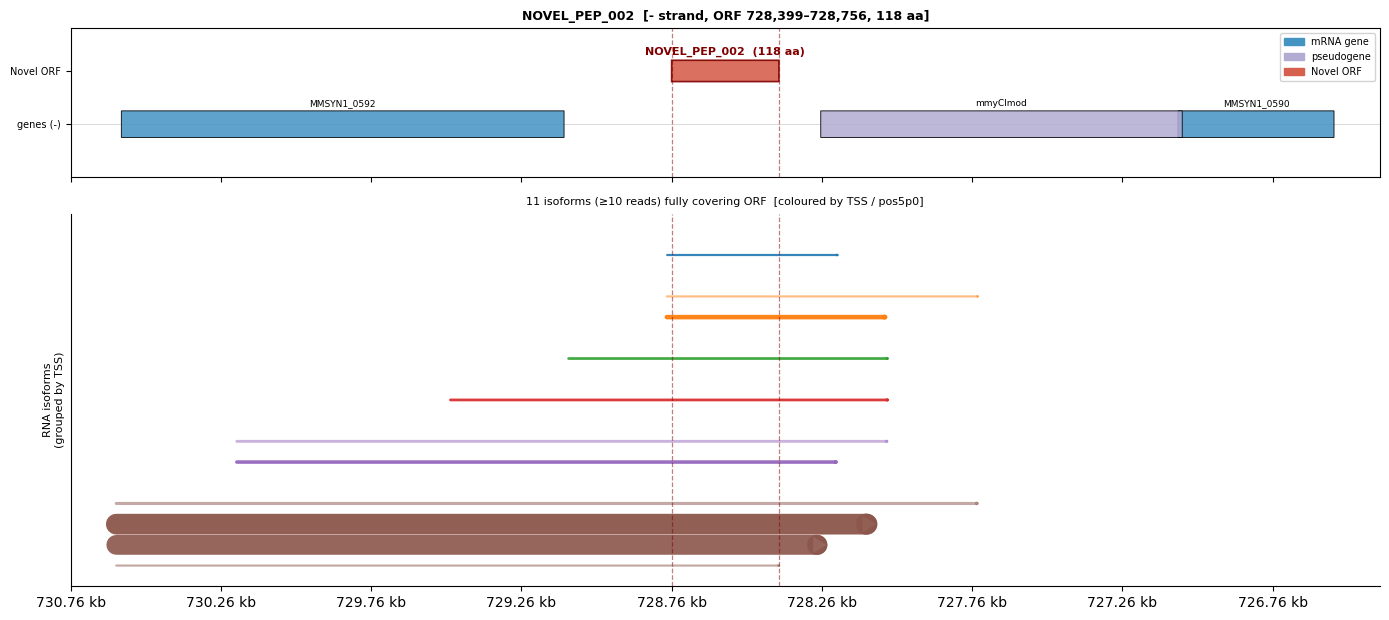

Figure saved: novel_pep_NOVEL_PEP_002_genomic_context.pdf
gs, ge: 905181 905859
win_s, win_e: 903181 907859
Isoforms fully covering ORF with ≥10 reads: 24


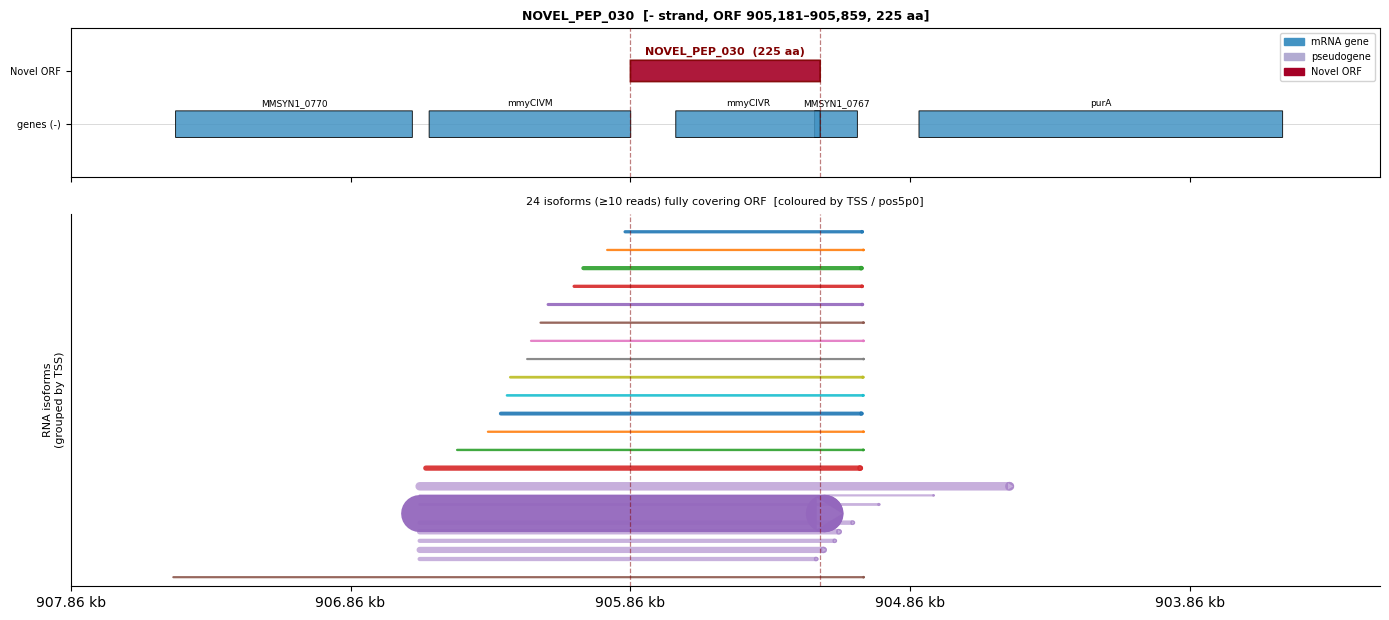

Figure saved: novel_pep_NOVEL_PEP_030_genomic_context.pdf


In [22]:
import math
from typing import List, Tuple

FOCUS          = ['NOVEL_PEP_002', 'NOVEL_PEP_030']  # 032 shares locus with 002
ISOFORM_TSV    = '../isoform_annotation/isoform_clusters_annotated.tsv'
CONTEXT_PAD    = 2000   # flanking bp shown either side of ORF
MIN_ISO_READS  = 10      # drop isoforms below this read count
MAX_ISOFORMS   = 120    # cap per panel
ISO_LW_SCALE   = 0.5    # linewidth = scale * sqrt(n_reads)
ISO_GAP        = 1      # blank rows between TSS groups

isoforms_all = pd.read_csv(ISOFORM_TSV, sep='\t')

# ── coordinate transform (mirrors OperonCoord.tx_of_genome_pos0) ─────────────
# Maps a genomic pos0 to a tx-space x where 5' end = small x, 3' end = large x.
# + strand: x = pos0 - win_s   (low coord is 5')
# - strand: x = win_e - pos0   (high coord is 5')
def tx(pos0: int, win_s: int, win_e: int, strand: str) -> int:
    if strand == '+':
        return pos0 - win_s
    else:
        return win_e - pos0

def tx_to_genome(x: int, win_s: int, win_e: int, strand: str) -> int:
    if strand == '+':
        return win_s + x
    else:
        return win_e - x

# ── interval packing (identical to Operon_Visualization) ─────────────────────
def _pack_rows(intervals: List[Tuple[int, int]]) -> List[int]:
    """Greedy non-overlapping row assignment, sorted by left endpoint."""
    order = sorted(range(len(intervals)), key=lambda i: (intervals[i][0], intervals[i][1]))
    row_ends: List[int] = []
    rows_out = [0] * len(intervals)
    for i in order:
        a, b = intervals[i]
        placed = False
        for r, end in enumerate(row_ends):
            if end <= a:
                row_ends[r] = b
                rows_out[i] = r
                placed = True
                break
        if not placed:
            row_ends.append(b)
            rows_out[i] = len(row_ends) - 1
    return rows_out


def layout_isoforms(iso_df: pd.DataFrame,
                    win_s: int, win_e: int,
                    orf_s: int, orf_e: int,
                    strand: str) -> pd.DataFrame:
    """
    Adapted directly from layout_isoform_tracks in Operon_Visualization.

    Key conventions (matching that notebook):
      start_pos0 = pos5p0  (5' end; high coord on minus strand)
      end_pos0   = pos3p0  (3' end; low coord on minus strand)

    Filter: keep isoforms that fully cover [orf_s, orf_e]
      i.e. start0 <= orf_s  AND  end0 >= orf_e  (genomic low/high coords)

    Coordinate transform: tx() maps genomic pos -> tx-space where
      x=0 is the left edge of the window and x increases left->right,
      with 5' end always mapping to a SMALLER x than the 3' end.
      This is identical to oc.tx_of_genome_pos0 in Operon_Visualization.

    Grouping: by start_pos0 (= pos5p0), sort=False (preserves pre-sort order).
    """
    iso = iso_df.copy()
    
    # Use the same column names as Operon_Visualization for clarity
    iso['start_pos0'] = iso['pos5p0']   # 5' end
    iso['end_pos0']   = iso['pos3p0']   # 3' end

    # Sort exactly as Operon_Visualization does:
    #   + strand: start_pos0 asc, end_pos0 asc, n_reads desc
    #   - strand: start_pos0 desc, end_pos0 desc, n_reads desc
    if strand == '+':
        iso = iso.sort_values(['start_pos0', 'end_pos0', 'n_reads'],
                              ascending=[True, True, False])
    else:
        iso = iso.sort_values(['start_pos0', 'end_pos0', 'n_reads'],
                              ascending=[False, False, False])
    iso = iso.head(MAX_ISOFORMS).copy()

    # Convert to tx-space, clip to window, then take min/max for left/right
    tx_lefts, tx_rights = [], []
    for _, r in iso.iterrows():
        s = int(r['start_pos0'])
        e = int(r['end_pos0'])
        s_clip = min(max(s, win_s), win_e)
        e_clip = min(max(e, win_s), win_e)
        x0 = tx(s_clip, win_s, win_e, strand)
        x1 = tx(e_clip, win_s, win_e, strand)
        tx_lefts.append(min(x0, x1))
        tx_rights.append(max(x0, x1))
    iso['tx_left']  = tx_lefts
    iso['tx_right'] = tx_rights
    iso = iso[iso['tx_right'] > iso['tx_left']].copy()
    if iso.empty:
        return iso

    # Thickness + alpha (same as Operon_Visualization)
    def thickness(n):
        return ISO_LW_SCALE * math.sqrt(max(0.0, float(n)))

    def _scale_alpha(n, nmin, nmax):
        if nmax <= nmin:
            return 0.9
        return float(0.5 + 0.45 * (n - nmin) / (nmax - nmin))

    iso['y']     = float('nan')
    iso['lw']    = float('nan')
    iso['alpha'] = float('nan')

    base_y = 0
    # sort=False preserves the pre-sort order within each group
    for g_start, g in iso.groupby('start_pos0', sort=False):
        g = g.sort_values(['n_reads', 'tx_right'], ascending=[False, True]).copy()
        intervals = list(zip(g['tx_left'].astype(int), g['tx_right'].astype(int)))
        rows  = _pack_rows(intervals)
        nvals = g['n_reads'].astype(float).to_numpy()
        nmin, nmax = float(nvals.min()), float(nvals.max())
        iso.loc[g.index, 'y']     = [base_y + r for r in rows]
        iso.loc[g.index, 'lw']    = [max(0.3, thickness(float(n))) for n in nvals]
        iso.loc[g.index, 'alpha'] = [_scale_alpha(float(n), nmin, nmax) for n in nvals]
        base_y += (max(rows) + 1) + ISO_GAP

    iso['group_id'] = iso['start_pos0'].astype(int)
    return iso


def draw_isoforms(ax, iso_df: pd.DataFrame,
                  win_s: int, win_e: int,
                  strand: str, orf_s: int, orf_e: int):
    """
    Draw isoforms as FancyArrowPatch, pointing in transcript direction.
    x-axis is tx-space (0 = left edge of window, increases right).
    Arrow always points right (5'->3' in tx-space), matching Operon_Visualization.
    """
    iso = layout_isoforms(iso_df, win_s, win_e, orf_s, orf_e, strand)
    # print("After layout_isoforms, the iso df is")
    # print(iso[["isoform_id", "start_pos0", "end_pos0", "tx_left", "tx_right", "y", "lw", "alpha"]].head(10)) 
    if iso.empty:
        ax.text(0.5, 0.5, 'No isoforms', transform=ax.transAxes,
                ha='center', va='center', fontsize=9, color='gray')
        ax.set_yticks([])
        return

    starts = sorted(iso['group_id'].unique())
    cmap   = plt.get_cmap('tab10')
    cdict  = {s: cmap(i % cmap.N) for i, s in enumerate(starts)}
    win_len = win_e - win_s

    for _, r in iso.iterrows():
        xl    = float(r['tx_left'])
        xr    = float(r['tx_right'])
        y     = float(r['y'])
        col   = cdict[int(r['group_id'])]
        lw    = float(r['lw'])
        alpha = float(r['alpha'])
        width = max(1.0, xr - xl)

        # Arrow always points right in tx-space (5'->3'), same as Operon_Visualization
        ax.add_patch(mpatches.FancyArrowPatch(
            (xl, y), (xr, y),
            arrowstyle='-|>',
            linewidth=lw, color=col, alpha=alpha,
            shrinkA=0, shrinkB=0,
        ))

    y_max = float(iso['y'].max())
    ax.set_xlim(0, win_len)
    ax.set_ylim(-1, y_max + 2)
    ax.set_yticks([])
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_ylabel('RNA isoforms\n(grouped by TSS)', fontsize=8)

    # x-axis labels as genomic coordinates
    _ws2, _we2, _st2 = win_s, win_e, strand
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _, ws=_ws2, we=_we2, st=_st2: f'{tx_to_genome(int(x), ws, we, st)/1000:.2f} kb'))


# ── gene-overlap text report ─────────────────────────────────────────────────
def gene_overlaps(genes_df, chrom, start0, end0, orf_strand):
    mask = ((genes_df['chrom'] == chrom) & (genes_df['start0'] < end0) &
            (genes_df['end0'] > start0))
    hits = genes_df[mask].copy()
    hits['relationship'] = hits['strand'].apply(
        lambda s: 'sense' if s == orf_strand else 'antisense')
    return hits

print('=' * 72)
print('2. Translated region projected onto genome — gene overlaps')
print('=' * 72)
for pid in FOCUS:
    row    = foc.loc[pid]
    gs, ge = int(row['orf_genomic_start0']), int(row['orf_genomic_end0'])
    strand = row['strand']
    ms_row = ms[ms['PG.ProteinAccessions'].str.contains(pid, na=False)]
    pg_n   = ms_row[PG_COL].values[0] if len(ms_row) else 'n/d'
    print(f'\n  {pid}  ({row["orf_aa_len"]} aa, {strand} strand)')
    print(f'    ORF coords: {gs:,}-{ge:,}  |  MS peptides (exp-wide): {pg_n}')
    overlap = gene_overlaps(genes, 'CP002027.1', gs, ge, strand)
    if overlap.empty:
        print('    Gene overlap: none (fully intergenic)')
    else:
        for _, gr in overlap.iterrows():
            ov_bp = min(ge, int(gr['end0'])) - max(gs, int(gr['start0']))
            name  = gr['gene_name'] if pd.notna(gr['gene_name']) else gr['locus_tag']
            print(f'    [{gr["relationship"].upper()}] {name} ({gr["locus_tag"]}, '
                  f'{gr["rna_type"]})  {int(gr["start0"]):,}-{int(gr["end0"]):,}  '
                  f'{ov_bp} bp  ({ov_bp/(ge-gs)*100:.0f}% of ORF / '
                  f'{ov_bp/(gr["end0"]-gr["start0"])*100:.0f}% of gene)')

# ── figure ───────────────────────────────────────────────────────────────────
GENE_COLORS = {'mRNA': '#4393C3', 'pseudo': '#B2ABD2', 'rRNA': '#E08214',
               'tRNA': '#7FBC41', 'tmRNA': '#E08214', 'ncRNA': '#DFC27D'}
ORF_COLORS  = {'NOVEL_PEP_002': '#D6604D', 'NOVEL_PEP_030': '#A50026'}

for i, pid in enumerate(FOCUS):
    fig, axes = plt.subplots(2, 1, figsize=(14, (1 + 2.5) * 1.8),
                             gridspec_kw={'height_ratios': [1, 2.5]},
                             sharex=False)
    ax_gene = axes[0]
    ax_iso  = axes[1]

    row    = foc.loc[pid]
    gs, ge = int(row['orf_genomic_start0']), int(row['orf_genomic_end0'])
    strand = row['strand']
    chrom  = 'CP002027.1'
    win_s  = gs - CONTEXT_PAD
    win_e  = ge + CONTEXT_PAD
    win_len = win_e - win_s
    print("gs, ge:", gs, ge)
    print("win_s, win_e:", win_s, win_e)
    # ── gene track (tx-space x-axis) ─────────────────────────────────────
    ctx = genes[
        (genes['chrom']  == chrom) &
        (genes['strand'] == strand) &
        (genes['start0']  > win_s) &
        (genes['end0']   < win_e)
    ]
    ax_gene.set_xlim(0, win_len)
    ax_gene.set_ylim(0, 2.8)
    ax_gene.axhline(1.0, color='#CCCCCC', lw=0.5, zorder=0)

    GENE_Y = 1.0;  GENE_H = 0.5
    for _, gr in ctx.iterrows():
        color = GENE_COLORS.get(gr['rna_type'], '#AAAAAA')
        # convert gene coords to tx-space
        gx0 = tx(int(gr['start0']), win_s, win_e, strand)
        gx1 = tx(int(gr['end0']),   win_s, win_e, strand)
        gxl, gxr = min(gx0, gx1), max(gx0, gx1)
        ax_gene.add_patch(mpatches.FancyBboxPatch(
            (gxl, GENE_Y - GENE_H/2), gxr - gxl, GENE_H,
            boxstyle='round,pad=0', lw=0.7,
            edgecolor='black', facecolor=color, alpha=0.85, zorder=2))
        label = gr['gene_name'] if pd.notna(gr['gene_name']) else gr['locus_tag']
        ax_gene.text((gxl + gxr) / 2, GENE_Y + GENE_H/2 + 0.05,
                     label, ha='center', va='bottom', fontsize=6.5, clip_on=True)

    ORF_Y = 2;  ORF_H = 0.4
    orf_color = ORF_COLORS.get(pid, '#E04444')
    # ORF coords in tx-space
    ox0 = tx(gs, win_s, win_e, strand)
    ox1 = tx(ge, win_s, win_e, strand)
    oxl, oxr = min(ox0, ox1), max(ox0, ox1)
    ax_gene.add_patch(mpatches.FancyBboxPatch(
        (oxl, ORF_Y - ORF_H/2), oxr - oxl, ORF_H,
        boxstyle='round,pad=0', lw=1.2,
        edgecolor='#800000', facecolor=orf_color, alpha=0.9, zorder=3))
    ax_gene.text((oxl + oxr) / 2, ORF_Y + ORF_H/2 + 0.06,
                 f'{pid}  ({row["orf_aa_len"]} aa)',
                 ha='center', va='bottom', fontsize=8, fontweight='bold',
                 color='#800000', clip_on=True)
    for xv in [oxl, oxr]:
        ax_gene.axvline(xv, color='#800000', lw=0.9, ls='--', alpha=0.5, zorder=4)

    ax_gene.set_yticks([GENE_Y, ORF_Y])
    ax_gene.set_yticklabels([f'genes ({strand})', 'Novel ORF'], fontsize=7)
    _ws, _we, _st = win_s, win_e, strand
    ax_gene.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _, ws=_ws, we=_we, st=_st: f'{tx_to_genome(int(x), ws, we, st)/1000:.2f} kb'))
    ax_gene.tick_params(axis='x', labelbottom=False)
    ax_gene.set_title(
        f'{pid}  [{strand} strand, ORF {gs:,}–{ge:,}, {row["orf_aa_len"]} aa]',
        fontsize=9, fontweight='bold')
    ax_gene.legend(handles=[
        mpatches.Patch(color=GENE_COLORS['mRNA'],   label='mRNA gene'),
        mpatches.Patch(color=GENE_COLORS['pseudo'],  label='pseudogene'),
        mpatches.Patch(color=orf_color,              label='Novel ORF'),
    ], fontsize=7, loc='upper right', framealpha=0.85)

    # ── isoform track ────────────────────────────────────────────────────
    iso_win = isoforms_all[
        (isoforms_all['chrom']  == chrom) &
        (isoforms_all['strand'] == strand) &
        (isoforms_all['start0'] <= gs) &
        (isoforms_all['n_reads'] >= MIN_ISO_READS) &
        (isoforms_all['end0']   >= ge)
    ].copy()
    
    print(f'Isoforms fully covering ORF with ≥{MIN_ISO_READS} reads: {len(iso_win)}')
    
    draw_isoforms(ax_iso, iso_win, win_s, win_e, strand, gs, ge)

    for xv in [oxl, oxr]:
        ax_iso.axvline(xv, color='#800000', lw=0.9, ls='--', alpha=0.5, zorder=5)

    ax_iso.set_title(
        f'{iso_win.shape[0]} isoforms (≥{MIN_ISO_READS} reads) fully covering ORF  '
        f'[coloured by TSS / pos5p0]',
        fontsize=8)

    plt.tight_layout()
    out_pdf = f'novel_pep_{pid}_genomic_context.pdf'
    fig.savefig(out_pdf, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {out_pdf}')


In [17]:
isoforms_all[isoforms_all['strand'] == "-"].head()

,isoform_id,chrom,strand,start0,end0,pos5p0,pos3p0,n_reads,start_spread_mad_bp,end_spread_mad_bp,start_key,end_key,isoform_len_bp,sense_overlap_bp,antisense_overlap_bp,intergenic_bp,frac_sense,frac_antisense,frac_intergenic,n_sense_genes,n_antisense_genes,sense_gene_ids,sense_gene_names,antisense_gene_ids,antisense_gene_names,class_main,class_detail,nearest_left_gene_id,nearest_left_gene_name,nearest_left_dist_bp,nearest_right_gene_id,nearest_right_gene_name,nearest_right_dist_bp
119,ISO_035507,CP002027.1,-,768,2616,2616,768,3,0.0,0.0,2600,750,1848,0,1691,157,0.0,0.915043,0.084957,0,2,NaN,NaN,"MMSYN1_0001,MMSYN1_0002","dnaA_1,dnaN",mixed,mixed_antisense_intergenic,NaN,NaN,NaN,MMSYN1_0003,rnmV,58.0
122,ISO_035508,CP002027.1,-,808,2616,2616,808,4,0.0,0.0,2600,780,1808,0,1651,157,0.0,0.913164,0.086836,0,2,NaN,NaN,"MMSYN1_0001,MMSYN1_0002","dnaA_1,dnaN",mixed,mixed_antisense_intergenic,NaN,NaN,NaN,MMSYN1_0003,rnmV,58.0
126,ISO_035509,CP002027.1,-,958,2616,2616,958,4,0.0,0.0,2600,930,1658,0,1501,157,0.0,0.905308,0.094692,0,2,NaN,NaN,"MMSYN1_0001,MMSYN1_0002","dnaA_1,dnaN",mixed,mixed_antisense_intergenic,NaN,NaN,NaN,MMSYN1_0003,rnmV,58.0
394,ISO_035514,CP002027.1,-,6104,9245,9245,6104,5,0.0,3.0,9240,6090,3141,0,3126,15,0.0,0.995224,0.004776,0,2,NaN,NaN,"MMSYN1_0006,MMSYN1_0007","gyrB,gyrA",antisense,antisense_multigene,MMSYN1_0005,hypothetical purine NTPase,949.0,MMSYN1_0008,ribose/Galactose ABC transporter_ permease com...,745.0
395,ISO_035510,CP002027.1,-,6113,7099,7099,6113,30,0.0,0.0,7080,6090,986,0,986,0,0.0,1.000000,0.000000,0,1,NaN,NaN,MMSYN1_0006,gyrB,antisense,antisense_single_gene,MMSYN1_0005,hypothetical purine NTPase,958.0,MMSYN1_0007,gyrA,335.0


In [13]:
# ── NOVEL_PEP_030: N-terminal extension peptide detection in mass spec ──────
import pandas as pd
import re

MS_FILE = "Mass_Spec/Syn1.0_newSearch_20260402.xlsx"

# Load Peptides_all sheet
pep_df = pd.read_excel(MS_FILE, sheet_name="Peptides_all")

# Identify quantity columns
quant_cols = [c for c in pep_df.columns if 'PEP.Quantity' in c]
print('Quantity columns:', quant_cols)

# Filter rows attributed to NOVEL_PEP_030
stripped_col = [c for c in pep_df.columns if 'Stripped' in c][0]
pg_acc_col   = [c for c in pep_df.columns if 'ProteinAccessions' in c or 'ProteinGroups' in c][0]
pep_030 = pep_df[pep_df[pg_acc_col].str.contains('NOVEL_PEP_030', na=False)].copy()
print(f'\nTotal peptide rows for NOVEL_PEP_030: {len(pep_030)}')

# Novel N-terminal extension sequence (54 aa, upstream of MMSYN1_0768 annotated start)
novel_ext = 'MALIEERKKERITSGSYERVLGNKKLGSLISMVHSTSISNGNELEKIILNKCKK'
print(f'\nNovel N-terminal extension ({len(novel_ext)} aa):')
print(novel_ext)

# In-silico tryptic digest (cut after K/R, not before P; min 6 aa; up to 1 missed cleavage)
def trypsin_digest(seq, missed=1):
    import re
    sites = [m.end() for m in re.finditer(r'[KR](?!P)', seq)]
    sites = [0] + sites + [len(seq)]
    peptides = []
    for i in range(len(sites) - 1):
        for j in range(i + 1, min(i + 2 + missed, len(sites))):
            pep = seq[sites[i]:sites[j]]
            if len(pep) >= 6:
                peptides.append(pep)
    return list(dict.fromkeys(peptides))

ext_peptides = trypsin_digest(novel_ext)
print(f'\nIn-silico tryptic peptides from extension (>=6 aa, <=1 missed cleavage):')
for p in ext_peptides:
    print(f'  {p}')

# Which extension peptides appear in the MS data?
detected_ext   = pep_030[pep_030[stripped_col].isin(ext_peptides)]
detected_other = pep_030[~pep_030[stripped_col].isin(ext_peptides)]

print(f'\n── Peptides from NOVEL N-TERMINAL EXTENSION detected in MS ({len(detected_ext)} rows) ──')
display_cols = [stripped_col] + quant_cols
print(detected_ext[display_cols].to_string(index=False))

print(f'\n── Peptides from SHARED region with MMSYN1_0768 ({len(detected_other)} rows) ──')
print(detected_other[display_cols].to_string(index=False))

# Abundance comparison
print('\n── SUMMARY ──')
print(f'Novel N-terminal extension: {len(novel_ext)} aa')
n_unique_ext = detected_ext[stripped_col].nunique()
print(f'Extension peptides detected by MS: {n_unique_ext} unique sequence(s)')
if len(detected_ext) > 0 and quant_cols:
    ext_mean    = detected_ext[quant_cols].astype(float).mean(axis=1).mean()
    shared_mean = detected_other[quant_cols].astype(float).mean(axis=1).mean()
    print(f'Mean abundance — extension peptides : {ext_mean:.2e}')
    print(f'Mean abundance — shared-region peptides: {shared_mean:.2e}')
    print(f'Ratio (shared / extension): {shared_mean / ext_mean:.1f}x')
    print('=> N-terminal extension peptides are detected but at lower stoichiometry,')
    print('   consistent with the novel isoform being a minor fraction of 0768 expression.')


Quantity columns: []

Total peptide rows for NOVEL_PEP_030: 23

Novel N-terminal extension (54 aa):
MALIEERKKERITSGSYERVLGNKKLGSLISMVHSTSISNGNELEKIILNKCKK

In-silico tryptic peptides from extension (>=6 aa, <=1 missed cleavage):
  MALIEER
  MALIEERK
  ERITSGSYER
  ITSGSYER
  ITSGSYERVLGNK
  VLGNKK
  KLGSLISMVHSTSISNGNELEK
  LGSLISMVHSTSISNGNELEK
  LGSLISMVHSTSISNGNELEKIILNK
  IILNKCK

── Peptides from NOVEL N-TERMINAL EXTENSION detected in MS (3 rows) ──
 PEP.StrippedSequence
             ITSGSYER
LGSLISMVHSTSISNGNELEK
LGSLISMVHSTSISNGNELEK

── Peptides from SHARED region with MMSYN1_0768 (20 rows) ──
PEP.StrippedSequence
            DGWVFDTK
            DGWVFDTK
         NLNFFVTELLK
         NLNFFVTELLK
            EEIFLGLK
        NSMEPDFLIIQK
        NSMEPDFLIIQK
        NSMEPDFLIIQK
        NSMEPDFLIIQK
            ELNSILQK
             IIEELSK
         SSETLNIIELK
         SSETLNIIELK
       EFDDSWDVIIVPK
       EFDDSWDVIIVPK
             SISFITK
   VAGEYQQLINFQNEISK
         IWIC